In [ ]:
import sys
sys.path.append('.')
import samna
import numpy as np
import matplotlib.pyplot as plt
import samna.dynapse1 as dyn1
import dynapse1utils as ut
from netgen import Neuron, NetworkGenerator
import params
from params import set_params
import time
from IPython.display import Image
import os 


In [ ]:
import samna

print("name:", samna.__name__)
print("file:", samna.__file__)
print("setup:", hasattr(samna, "setup_local_node"))

In [ ]:

print("name:", samna.__name__)
print("file:", samna.__file__)
print("\n")
print("setup:", hasattr(samna, "setup_local_node"))

In [ ]:
!which python3 --version
!python --version

## LOCAL

In [ ]:
# devices = samna.device.get_unopened_devices()

# print(devices)

# try:
#     model, gui = ut.open_dynapse1(gui=False,select_device=True)
# except AttributeError as e:
#     print("\nno board attached") 
#     print(e)
#python -c "import samna; print(samna.device.get_all_devices())"
# [device::DeviceInfo(serial_number=00000007, usb_bus_number=2, usb_device_address=3, logic_version=5, device_type_name=Dynapse1DevKit)]

# devices = samna.device.get_all_devices()
# print(devices)  # Ist das Gerät hier noch sichtbar?\
# model = samna.device.open_device(devices[0])
if os.system("uname")== "Darwin":
    model, _ = ut.open_dynapse1()

# print(samna.device.get_all_devices())
# devices = samna.device.get_all_devices(); [print(d) for d in devices]


In [ ]:
print(samna)
print(samna.__file__)


In [ ]:

print(type(samna))
print(dir(samna)[:50])

In [ ]:
print(hasattr(samna, "setup_local_node"))
print(hasattr(samna, "open_remote_node"))
print(hasattr(samna, "device"))

In [ ]:


print(hasattr(samna, "setup_local_node"))
print(hasattr(samna, "open_remote_node"))

In [ ]:
[x for x in dir(samna) if "setup" in x.lower()]


## SERVER SIDE ZEMO

In [ ]:
# open DYNAP-SE1 board to get Dynapse1Model

# The open_dynapse1 utility will ini
# 
# tialize communication with the device
# - gui=False: do not open any graphical interface --> the DYNAPSE1 GUI does not work if you connect remotely
# - select_device=True: allow user/device selection if multiple boards are detected --> this is necessary when you are connecting via Zemo, since there is more than 1 board attached

model, _ = ut.open_dynapse1(gui=False, select_device=True)


In [ ]:
# get Dynapse1 api from the model
api = model.get_dynapse1_api()

In [ ]:
# set standard parameters
set_params(model)

In [ ]:
config1 = model.get_configuration() 

Remember how to set the parameters. Below you have a reference figure that you can use to understand how setting the "coarse" and "fine" values for the DYNAP-SE1 chip works.

In [ ]:
Image("lab5/params_coarse_fine.png")

# New poulation 

In [ ]:
# 4 Channels definieren
channels = {
    0: list(range(0, 16)),
    1: list(range(16, 32)),
    2: list(range(32, 48)),
    3: list(range(48, 64))
}


param_group = config1.chips[0].cores[0].parameter_group 

In [472]:
 
import os 


T        = 1.0          # total duration (s)
RATE     = 32           # spikes per second (deterministic, linspace)
N_SPIKES = int(T * RATE)  # = 32 spikes
 
# Per-channel time shifts (ms) — ch0 is aligned to reference
J_SHIFT_PARAM = [0, 10, 25, 50]   # [ch0, ch1, ch2, ch3]
J_SHIFT_PARAM = [12.0, 8.0, 0.0, 4.0]  # ms
N_CH = 4
error_e= 0.20 ## msec
 
 
#spike generation ─────────────────────────────────────────────────────────────────────────────
# Reference: evenly spaced over [0, T)
t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)
t_ref_shifted = (t_ref + error_e) % T
# Each channel: same grid, shifted by epsilon_k
# Spikes that go past T are wrapped (modulo T) so count stays constant

##j is the shift parameter for matching $\epsilon$ is 
    #the error rate which the shift can have be to still exicte 

t_ch = []
for j_ms in J_SHIFT_PARAM:
    j_shift  = j_ms * 1e-3 
    t_raw  = t_ref + j_shift 
    t_wrap = t_raw % T          # wrap around
    t_ch.append(np.sort(t_wrap))
# ─────────────────────────────────────────────────────────────────────────────
 
# print(f"{t_ch[0]}\n")
# print(f"{t_ch[1]}\n")
# print(t_ch)
###__________ dicts of channels
## sort list with 2 
dict_list = []

for ch_idx, arr in enumerate(t_ch):
    d = {f"ch_{ch_idx}:{i}": val for i, val in enumerate(arr)}
    dict_list.append(d)

# Separate Variablen:
dict_ch0 = dict_list[0]
dict_ch1 = dict_list[1]
dict_ch2 = dict_list[2]
dict_ch3 = dict_list[3]

print(f"dict_ch0:{dict_ch0}")
dict_ch0={key:val+error_e for key,val in dict_ch0.items()}
print(f"shifted by {error_e}")


print(f"{t_ch[0]}")
print(f"d={dict_ch0}")
###__________ dicts of channels

###_______________ combinded dicts + + list lookup
#zip all values togetherto a list and also the order of the keys 
# Alle Dicts zusammenführen
combined = {}
for d in [dict_ch0, dict_ch1, dict_ch2, dict_ch3]:
    combined.update(d)

# Sortiert nach Value aufsteigend
sorted_items = sorted(combined.items(), key=lambda x: x[1])

# Zwei Listen: values zum senden, keys als lookup
values_list = [val for key, val in sorted_items]   # zum senden
keys_list   = [key for key, val in sorted_items]   # lookup: welcher channel/index

print(f"value_list{values_list}")
print(f"key_list{keys_list}")
print(f"\nt_ref{t_ref}")
print(f"\nt_ref_shifted{t_ref_shifted}")
###_______________ combinded dicts + list lookup


len(t_ch[0])

dict_ch0:{'ch_0:0': 0.012, 'ch_0:1': 0.04325, 'ch_0:2': 0.0745, 'ch_0:3': 0.10575, 'ch_0:4': 0.137, 'ch_0:5': 0.16825, 'ch_0:6': 0.1995, 'ch_0:7': 0.23075, 'ch_0:8': 0.262, 'ch_0:9': 0.29325, 'ch_0:10': 0.3245, 'ch_0:11': 0.35575, 'ch_0:12': 0.387, 'ch_0:13': 0.41825, 'ch_0:14': 0.4495, 'ch_0:15': 0.48075, 'ch_0:16': 0.512, 'ch_0:17': 0.54325, 'ch_0:18': 0.5745, 'ch_0:19': 0.60575, 'ch_0:20': 0.637, 'ch_0:21': 0.66825, 'ch_0:22': 0.6995, 'ch_0:23': 0.73075, 'ch_0:24': 0.762, 'ch_0:25': 0.79325, 'ch_0:26': 0.8245, 'ch_0:27': 0.85575, 'ch_0:28': 0.887, 'ch_0:29': 0.91825, 'ch_0:30': 0.9495, 'ch_0:31': 0.98075}
shifted by 0.2
[0.012   0.04325 0.0745  0.10575 0.137   0.16825 0.1995  0.23075 0.262
 0.29325 0.3245  0.35575 0.387   0.41825 0.4495  0.48075 0.512   0.54325
 0.5745  0.60575 0.637   0.66825 0.6995  0.73075 0.762   0.79325 0.8245
 0.85575 0.887   0.91825 0.9495  0.98075]
d={'ch_0:0': 0.21200000000000002, 'ch_0:1': 0.24325000000000002, 'ch_0:2': 0.2745, 'ch_0:3': 0.30575, 'ch_0:4':

32

In [473]:
## set the shifting of the reference line 
error_e= 0.020 ## msec
 
 
#spike generation ─────────────────────────────────────────────────────────────────────────────
# Reference: evenly spaced over [0, T)
# t_ref = np.linspace(0, T, N_SPIKES, endpoint=False)
t_ref = (t_ref + error_e) % T

# print(type(t_ref_shifted))
# print(type(t_ref))

In [474]:
##############################################################################
# REFERENCE
##############################################################################

t_ref = np.linspace(
    0,
    T,
    N_SPIKES,
    endpoint=False
)

epsilon_ref = 0.020

t_ref = (
    t_ref + epsilon_ref
) % T

##############################################################################
# CHANNELS
##############################################################################

t_ch = []

for j_ms in J_SHIFT_PARAM:

    j_shift = j_ms * 1e-3

    t_raw = t_ref + j_shift

    t_ch.append(
        np.sort(
            t_raw % T
        )
    )


In [475]:
print(t_ref[:5])

for i in range(4):
    print(
        f"ch{i}",
        t_ch[i][:5]
    )

[0.02    0.05125 0.0825  0.11375 0.145  ]
ch0 [0.00075 0.032   0.06325 0.0945  0.12575]
ch1 [0.028   0.05925 0.0905  0.12175 0.153  ]
ch2 [0.02    0.05125 0.0825  0.11375 0.145  ]
ch3 [0.024   0.05525 0.0865  0.11775 0.149  ]


In [476]:
#test test this is a test
combined["ch_0:12"]

0.587

=== Reference spike times (s) ===
[0.02   0.0512 0.0825 0.1138 0.145  0.1762 0.2075 0.2388 0.27   0.3012
 0.3325 0.3638 0.395  0.4262 0.4575 0.4888 0.52   0.5512 0.5825 0.6138
 0.645  0.6762 0.7075 0.7388 0.77   0.8012 0.8325 0.8638 0.895  0.9262
 0.9575 0.9888]

=== Channel 0  (j_shift = 12.0 ms) ===
[8.000e-04 3.200e-02 6.320e-02 9.450e-02 1.258e-01 1.570e-01 1.882e-01
 2.195e-01 2.507e-01 2.820e-01 3.133e-01 3.445e-01 3.758e-01 4.070e-01
 4.382e-01 4.695e-01 5.008e-01 5.320e-01 5.632e-01 5.945e-01 6.258e-01
 6.570e-01 6.882e-01 7.195e-01 7.508e-01 7.820e-01 8.132e-01 8.445e-01
 8.758e-01 9.070e-01 9.382e-01 9.695e-01]

=== Channel 1  (j_shift = 8.0 ms) ===
[0.028  0.0592 0.0905 0.1218 0.153  0.1842 0.2155 0.2468 0.278  0.3093
 0.3405 0.3718 0.403  0.4342 0.4655 0.4968 0.528  0.5592 0.5905 0.6218
 0.653  0.6842 0.7155 0.7468 0.778  0.8092 0.8405 0.8718 0.903  0.9342
 0.9655 0.9968]

=== Channel 2  (j_shift = 0.0 ms) ===
[0.02   0.0512 0.0825 0.1138 0.145  0.1762 0.2075 0.2388 0.27   

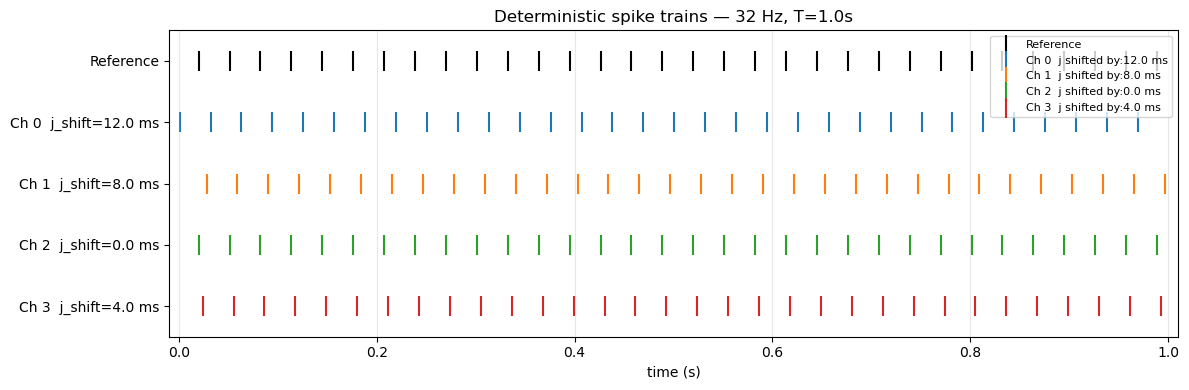


Plot saved to step1_spikes.png


In [477]:
print("=== Reference spike times (s) ===")
print(np.round(t_ref, 4))
 
for ch in range(N_CH):
    print(f"\n=== Channel {ch}  (j_shift = {J_SHIFT_PARAM[ch]} ms) ===")
    print(np.round(t_ch[ch], 4))
 
# ─────────────────────────────────────────────────────────────────────────────
# RASTER PLOT
# ─────────────────────────────────────────────────────────────────────────────
 
fig, ax = plt.subplots(figsize=(12, 4))
 
# y-positions: reference at top (row N_CH), channels below (N_CH-1 down to 0)
COLORS = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
 
# Reference
y_ref = N_CH
ax.scatter(t_ref, np.full_like(t_ref, y_ref),
           marker='|', s=200, linewidths=1.5, color='black', label='Reference')
 
# Channels
for ch in range(N_CH):
    y = N_CH - 1 - ch
    ax.scatter(t_ch[ch], np.full_like(t_ch[ch], y),
               marker='|', s=200, linewidths=1.5,
               color=COLORS[ch], label=f'Ch {ch}  j shifted by:{J_SHIFT_PARAM[ch]} ms')
 
# Formatting
ax.set_yticks(range(N_CH + 1))
ax.set_yticklabels(
    [f'Ch {N_CH-1-i}  j_shift={J_SHIFT_PARAM[N_CH-1-i]} ms' for i in range(N_CH)] + ['Reference']
)
ax.set_xlabel('time (s)')
ax.set_title(f'Deterministic spike trains — {RATE} Hz, T={T}s')
ax.set_xlim(-0.01, T + 0.01)
ax.set_ylim(-0.5, N_CH + 0.5)
ax.legend(loc='upper right', fontsize=8)
ax.grid(axis='x', alpha=0.3)
 
plt.tight_layout()
files_found= sys


plot_number_in_dir = len([name for name in os.listdir('./keyspot_plots') if os.path.isfile(os.path.join('./keyspot_plots', name))])
print(plot_number_in_dir)
plt.savefig(f'keyspot_plots/step1_spikes{plot_number_in_dir}.png', dpi=150)



plt.show()
print("\nPlot saved to step1_spikes.png")

In [478]:
!pwd 

/home/dyuser-a/keyspotting/dynap-se1


In [479]:
!ls -a 

 .				       netgen.py
 ..				       network_primitives
 board_registry			       parameters
 details			       params.py
 doc				       __pycache__
 .DS_Store			       pygetscope
 dynapse1constants.py		       pyspcmscope
 dynapse1utils.py		       Readme.md
 dynapse-biases-howtosetup.md	       register.sh
 example			       requirements.38.txt
 .gitignore			       samna_info.json
 .gitlab-ci.yml			       samna.log
 .gitmodules			       stdp_algorithms
 global_setup_review		       stdp.py
 .ipynb_checkpoints		       stdp_utils.py
 jupyterlab-experiments		       step1_spikes.png
 keyspot_plots			       step3_wta_result.png
'keyspot_plots\step3_wta_result.png'   test
 lab5				       tools
 Lab5_P1_p_CH03_recovery.ipynb	       tutorials
 Lab5_P1_p.ipynb		       venv_samna
 live_gui			       wta_4ch_result.png


# GLOBAL SETUP:
### for all params 

In [480]:
###############################################################################
# GLOBAL CONTROLLER
#
# Diese Zelle enthält ausschließlich Werte, die man manuell verändert.
# Keine Spike-Erzeugung, keine Netzwerk-Erzeugung, keine FPGA-Programmierung.
###############################################################################


# =============================================================================
# 1. HARDWARE / FPGA
# =============================================================================

TARGET_CHIP = 0

MAX_ISI = 2**24
MAX_FPGA_LEN = 2**16

# FPGA tick:
# 900 / 90 MHz = 10 microseconds
ISI_BASE = 900


# =============================================================================
# 2. INPUT-SIGNAL
# =============================================================================

T = 1.0
RATE = 32
N_CH = 4

# # Gemeinsamer Start-Shift des vollständigen Signals.
# # Einheit ausschließlich Millisekunden.
# REFERENCE_SHIFT_MS = 20.0

# # Relativer Shift jedes Kanals gegenüber der Referenz.
# # Channel 0 ist vollständig aligned.
# CHANNEL_SHIFT_MS = [0.0, 10.0, 25.0, 50.0]

# N_SPIKES = int(T * RATE)

# epsilon_ref = 0.020

# J_SHIFT_PARAM = [0.0, 4.0, 8.0, 12.0]
# N_CH = len(J_SHIFT_PARAM)
###############

T = 1.0
RATE = 32

EPSILON_REF_MS = 20.0
J_SHIFT_PARAM = [0.0, 10.0, 25.0, 50.0]
J_SHIFT_PARAM = [12.0, 8.0, 0.0, 4.0]  # ms # CH=02 wins

STIMULATION_DURATION = 3.0
POST_STIMULATION_DURATION = 2.0

FPGA_REPEAT_MODE = True



# =============================================================================
# 3. SPIKE-GENERATOR LAYOUT
# =============================================================================

SPIKEGEN_START_ID = 1
REFERENCE_NRN = 5


# =============================================================================
# 4. COINCIDENCE-DETECTION NETWORK
# =============================================================================

MATCH_NEURONS_PER_CHANNEL = 16
INH_NEURONS_PER_CHANNEL = 4

MATCH_START_ID = 1
INH_START_ID = 65

ENABLE_LOCAL_INHIBITION = True

## FOR new WTA update 
# Hardware layout
SPIKEGEN_CHIP = 0
SPIKEGEN_CORE = 1

NETWORK_CHIP = 0
NETWORK_CORE = 0

# Synapse types
INPUT_TO_MATCH_SYN_TYPE = dyn1.Dynapse1SynType.AMPA
REFERENCE_TO_MATCH_SYN_TYPE = dyn1.Dynapse1SynType.AMPA
MATCH_TO_INH_SYN_TYPE = dyn1.Dynapse1SynType.AMPA
WTA_INH_SYN_TYPE = dyn1.Dynapse1SynType.GABA_B
LOCAL_INH_SYN_TYPE = dyn1.Dynapse1SynType.GABA_A

# Apply the current parameter group before running
APPLY_PARAM_GROUP = True


# =============================================================================
# 5. EXPERIMENT
# =============================================================================

STIMULATION_DURATION = 3.0
POST_STIMULATION_DURATION = 2.0

FPGA_REPEAT_MODE = True


# =============================================================================
# 6. ANALYSIS
# =============================================================================

ANALYSIS_FS = 500
RATE_KERNEL_SIGMA = 0.05

WINNER_SCORE_EPSILON = 1e-12


# =============================================================================
# 7. OUTPUT / DEBUG
# =============================================================================

PRINT_GLOBAL_CONFIG = True
PRINT_FIRST_N_SPIKES = 5
SAVE_PLOTS = True
PLOT_DIRECTORY = "./keyspot_plots"


N_SPIKES = int(T * RATE)
TOTAL_DURATION = STIMULATION_DURATION + POST_STIMULATION_DURATION

SPIKEGEN_NEURON = {
    ch: SPIKEGEN_START_ID + ch
    for ch in range(N_CH)
}

MATCH_CH = MATCH_NEURONS_PER_CHANNEL
INH_CH = INH_NEURONS_PER_CHANNEL

D_stim = STIMULATION_DURATION
D_post = POST_STIMULATION_DURATION
D = TOTAL_DURATION
fs = ANALYSIS_FS
sigma = RATE_KERNEL_SIGMA

# GLOBAL DERIVED VALUES 
### check back on values initialized 

In [481]:
# ###############################################################################
# # GLOBAL DERIVED VALUES
# #
# # Nicht manuell bearbeiten.
# # Diese Größen werden ausschließlich aus GLOBAL CONTROLLER berechnet.
# ###############################################################################


# # =============================================================================
# # 1. DERIVED EXPERIMENT VALUES
# # =============================================================================

# N_SPIKES = int(T * RATE)
# TOTAL_DURATION = STIMULATION_DURATION + POST_STIMULATION_DURATION

# REFERENCE_SHIFT_S = REFERENCE_SHIFT_MS * 1e-3
# CHANNEL_SHIFT_S = np.asarray(CHANNEL_SHIFT_MS, dtype=float) * 1e-3


# # =============================================================================
# # 2. DERIVED SPIKE-GENERATOR IDS
# # =============================================================================

# SPIKEGEN_NEURON = {ch: SPIKEGEN_START_ID + ch for ch in range(N_CH)}


# # =============================================================================
# # 3. DERIVED NETWORK IDS
# # =============================================================================

# MATCH_CH = MATCH_NEURONS_PER_CHANNEL
# INH_CH = INH_NEURONS_PER_CHANNEL

# MATCH_IDS = [
#     Neuron(0, 0, neuron_id)
#     for neuron_id in range(
#         MATCH_START_ID,
#         MATCH_START_ID + N_CH * MATCH_CH
#     )
# ]

# INH_IDS = [
#     Neuron(0, 0, neuron_id)
#     for neuron_id in range(
#         INH_START_ID,
#         INH_START_ID + N_CH * INH_CH
#     )
# ]


# # =============================================================================
# # 4. COMPATIBILITY NAMES
# # =============================================================================

# #J_SHIFT_PARAM = CHANNEL_SHIFT_MS
# D_stim = STIMULATION_DURATION
# D_post = POST_STIMULATION_DURATION
# D = TOTAL_DURATION
# fs = ANALYSIS_FS
# sigma = RATE_KERNEL_SIGMA




###############################################################################
# GLOBAL DERIVED VALUES
###############################################################################


T = 1.0
RATE = 32

EPSILON_REF_MS = 20.0
J_SHIFT_PARAM = [0.0, 10.0, 25.0, 50.0]
J_SHIFT_PARAM = [12.0, 8.0, 0.0, 4.0]  # ms CH02 wins

STIMULATION_DURATION = 3.0
POST_STIMULATION_DURATION = 2.0
FPGA_REPEAT_MODE = True
# Experiment
N_SPIKES = int(T * RATE)
TOTAL_DURATION = STIMULATION_DURATION + POST_STIMULATION_DURATION

# Timing
EPSILON_REF_S = EPSILON_REF_MS * 1e-3
J_SHIFT_S = np.asarray(J_SHIFT_PARAM, dtype=float) * 1e-3

# Compatibility names for plots and filenames
REFERENCE_SHIFT_MS = EPSILON_REF_MS
CHANNEL_SHIFT_MS = J_SHIFT_PARAM.copy()

# Spike-generator IDs
SPIKEGEN_NEURON = {
    ch: SPIKEGEN_START_ID + ch
    for ch in range(N_CH)
}

# Network sizes
MATCH_CH = MATCH_NEURONS_PER_CHANNEL
INH_CH = INH_NEURONS_PER_CHANNEL

# Compatibility names
D_stim = STIMULATION_DURATION
D_post = POST_STIMULATION_DURATION
D = TOTAL_DURATION
fs = ANALYSIS_FS
sigma = RATE_KERNEL_SIGMA

In [483]:
###############################################################################
# SPIKE TIME GENERATION
###############################################################################

t_ref = np.linspace(
    0.0,
    T,
    N_SPIKES,
    endpoint=False
)

t_ref = np.sort(
    (t_ref + epsilon_ref) % T
)

t_ch = [
    np.sort(
        (t_ref + j_ms * 1e-3) % T
    )
    for j_ms in J_SHIFT_PARAM
]

print("CH00 == REF is of ")
#assert np.allclose(t_ch[0], t_ref)

CH00 == REF is of 


# Kompakte version 

In [484]:
# ###############################################################################
# # GLOBAL DERIVED VALUES — NICHT MANUELL BEARBEITEN
# ###############################################################################

# N_SPIKES = int(T * RATE)
# TOTAL_DURATION = STIMULATION_DURATION + POST_STIMULATION_DURATION

# REFERENCE_SHIFT_S = REFERENCE_SHIFT_MS * 1e-3
# CHANNEL_SHIFT_S = np.asarray(CHANNEL_SHIFT_MS, dtype=float) * 1e-3

# SPIKEGEN_NEURON = {ch: SPIKEGEN_START_ID + ch for ch in range(N_CH)}

# MATCH_CH = MATCH_NEURONS_PER_CHANNEL
# INH_CH = INH_NEURONS_PER_CHANNEL

# MATCH_IDS = [Neuron(0, 0, neuron_id) for neuron_id in range(MATCH_START_ID, MATCH_START_ID + N_CH * MATCH_CH)]
# INH_IDS = [Neuron(0, 0, neuron_id) for neuron_id in range(INH_START_ID, INH_START_ID + N_CH * INH_CH)]

# J_SHIFT_PARAM = CHANNEL_SHIFT_MS
# D_stim = STIMULATION_DURATION
# D_post = POST_STIMULATION_DURATION
# D = TOTAL_DURATION
# fs = ANALYSIS_FS
# sigma = RATE_KERNEL_SIGMA

# Checkup for any false initialization 

In [485]:
###############################################################################
# GLOBAL VALIDATION
###############################################################################

assert T > 0, "T must be greater than zero."
assert RATE > 0, "RATE must be greater than zero."
assert N_CH > 0, "N_CH must be greater than zero."

assert len(CHANNEL_SHIFT_MS) == N_CH, (
    f"CHANNEL_SHIFT_MS contains {len(CHANNEL_SHIFT_MS)} values, "
    f"but N_CH is {N_CH}."
)

assert REFERENCE_SHIFT_MS >= 0, "REFERENCE_SHIFT_MS must not be negative."
assert all(shift >= 0 for shift in CHANNEL_SHIFT_MS), "Channel shifts must not be negative."

assert len(set(SPIKEGEN_NEURON.values())) == N_CH, "Spike-generator IDs must be unique."
assert REFERENCE_NRN not in SPIKEGEN_NEURON.values(), "Reference neuron overlaps with an input neuron."

assert N_SPIKES * (N_CH + 1) <= MAX_FPGA_LEN, (
    "The FPGA event stream exceeds MAX_FPGA_LEN."
)

assert STIMULATION_DURATION > 0, "STIMULATION_DURATION must be greater than zero."
assert POST_STIMULATION_DURATION >= 0, "POST_STIMULATION_DURATION must not be negative."

if PRINT_GLOBAL_CONFIG:
    print("GLOBAL CONFIGURATION")
    print("====================")
    print(f"Channels:                 {N_CH}")
    print(f"Signal duration:          {T:.3f} s")
    print(f"Rate:                     {RATE} Hz")
    print(f"Spikes per signal:        {N_SPIKES}")
    print(f"Reference shift:          {REFERENCE_SHIFT_MS:.3f} ms")
    print(f"Channel shifts:           {CHANNEL_SHIFT_MS} ms")
    print(f"Match neurons/channel:    {MATCH_CH}")
    print(f"Inhibitory neurons/ch:    {INH_CH}")
    print(f"Stimulation duration:     {STIMULATION_DURATION:.3f} s")
    print(f"Post duration:            {POST_STIMULATION_DURATION:.3f} s")

GLOBAL CONFIGURATION
Channels:                 4
Signal duration:          1.000 s
Rate:                     32 Hz
Spikes per signal:        32
Reference shift:          20.000 ms
Channel shifts:           [12.0, 8.0, 0.0, 4.0] ms
Match neurons/channel:    16
Inhibitory neurons/ch:    4
Stimulation duration:     3.000 s
Post duration:            2.000 s


In [486]:
# =============================================================================
# 7. OUTPUT / DEBUG
# =============================================================================

PRINT_GLOBAL_CONFIG = True
PRINT_FIRST_N_SPIKES = 5

SHOW_SETUP_PLOT = True
SAVE_SETUP_PLOT = True

PLOT_DIRECTORY = "./global_setup_review"
# SETUP_PLOT_FILENAME = "global_setup_preview.png"
shift_name = "-".join(f"{shift:g}" for shift in CHANNEL_SHIFT_MS)

SETUP_PLOT_FILENAME = (
    f"setup_"
    f"rate{RATE}Hz_"
    f"ref{REFERENCE_SHIFT_MS:g}ms_"
    f"shift{shift_name}ms_"
    f"match{MATCH_CH}_"
    f"inh{INH_CH}.png"
)

In [487]:
###############################################################################
# SPIKE TIME GENERATION
#
# Reference = deterministic linspace grid shifted by epsilon_ref
# Channels  = reference shifted by j_k
###############################################################################

# Unverschobenes deterministisches Zeitraster
t_ref_base = np.linspace(0.0, T, N_SPIKES, endpoint=False)

# Referenzsignal
t_ref = np.sort((t_ref_base + EPSILON_REF_S) % T)

# Channel k = Referenz + j_k
t_ch = [np.sort((t_ref_base + EPSILON_REF_S + j_shift) % T) for j_shift in J_SHIFT_S]


# =============================================================================
# VALIDATION
# =============================================================================

assert len(t_ch) == N_CH
assert all(len(channel) == N_SPIKES for channel in t_ch)

print("Channel 0 == REF is of" )
### zero channel align ref
#assert np.allclose(t_ch[0], t_ref), "Channel 0 must be aligned with the reference."


# =============================================================================
# SHORT PRINT
# =============================================================================

n = min(PRINT_FIRST_N_SPIKES, N_SPIKES)

print("=" * 60)
print("REFERENCE AND CHANNEL GENERATION")
print("=" * 60)

print(f"Reference base : {np.round(t_ref_base[:n], 6)}")
print(f"Reference      : {np.round(t_ref[:n], 6)}")

for ch in range(N_CH):
    print(
        f"Channel {ch} "
        f"(j={J_SHIFT_PARAM[ch]:g} ms): "
        f"{np.round(t_ch[ch][:n], 6)}"
    )

print(f"\nChannel 0 aligned: {np.allclose(t_ch[0], t_ref)}")
print("=" * 60)

Channel 0 == REF is of
REFERENCE AND CHANNEL GENERATION
Reference base : [0.      0.03125 0.0625  0.09375 0.125  ]
Reference      : [0.02    0.05125 0.0825  0.11375 0.145  ]
Channel 0 (j=12 ms): [0.00075 0.032   0.06325 0.0945  0.12575]
Channel 1 (j=8 ms): [0.028   0.05925 0.0905  0.12175 0.153  ]
Channel 2 (j=0 ms): [0.02    0.05125 0.0825  0.11375 0.145  ]
Channel 3 (j=4 ms): [0.024   0.05525 0.0865  0.11775 0.149  ]

Channel 0 aligned: False


In [488]:
###############################################################################
# TIMING DEBUG — EFFECTIVE DISTANCE TO REFERENCE
###############################################################################

period_ms = 1000.0 / RATE

print("=" * 65)
print("EFFECTIVE COINCIDENCE DISTANCES")
print("=" * 65)
print(f"Spike period: {period_ms:.3f} ms\n")

for ch in range(N_CH):
    distance = np.abs(t_ch[ch][:, None] - t_ref[None, :])
    circular_distance = np.minimum(distance, T - distance)
    nearest_ms = circular_distance.min(axis=1) * 1000

    print(
        f"Channel {ch} | j={J_SHIFT_PARAM[ch]:6g} ms | "
        f"nearest Ref: min={nearest_ms.min():7.3f} ms, "
        f"mean={nearest_ms.mean():7.3f} ms, "
        f"max={nearest_ms.max():7.3f} ms"
    )

print("=" * 65)

EFFECTIVE COINCIDENCE DISTANCES
Spike period: 31.250 ms

Channel 0 | j=    12 ms | nearest Ref: min= 12.000 ms, mean= 12.000 ms, max= 12.000 ms
Channel 1 | j=     8 ms | nearest Ref: min=  8.000 ms, mean=  8.000 ms, max=  8.000 ms
Channel 2 | j=     0 ms | nearest Ref: min=  0.000 ms, mean=  0.000 ms, max=  0.000 ms
Channel 3 | j=     4 ms | nearest Ref: min=  4.000 ms, mean=  4.000 ms, max=  4.000 ms


EXPERIMENT SETUP BEFORE WTA
Target chip             : 0
Number of channels      : 4
Signal duration         : 1.000 s
Input rate              : 32 Hz
Spikes per signal       : 32
Reference shift         : 20.000 ms
Channel shifts          : [12.0, 8.0, 0.0, 4.0] ms
FPGA repeat mode        : True
Stimulation duration    : 3.000 s
Post-stimulation        : 2.000 s
Match neurons/channel   : 16
Inhibitory neurons/ch.  : 4

First 5 spike times:
Reference : [0.02    0.05125 0.0825  0.11375 0.145  ]
Channel 0 : [0.00075 0.032   0.06325 0.0945  0.12575]
Channel 1 : [0.028   0.05925 0.0905  0.12175 0.153  ]
Channel 2 : [0.02    0.05125 0.0825  0.11375 0.145  ]
Channel 3 : [0.024   0.05525 0.0865  0.11775 0.149  ]

Alignment check:
Channel 0 == Reference  : False
Minimum event time      : 0.000750 s
Maximum event time      : 0.996750 s

Setup plot saved: ./global_setup_review/setup_rate32Hz_ref20ms_shift12-8-0-4ms_match16_inh4.png


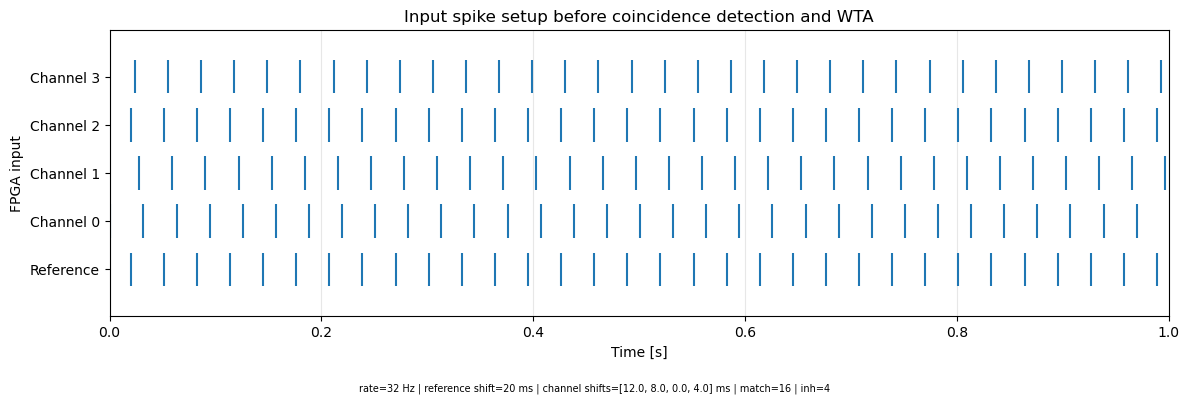

In [489]:
###############################################################################
# SETUP PREVIEW
#
# Letzte Kontrolle des vollständigen Inputs vor dem Aufbau des WTA-Netzwerks.
###############################################################################

if PRINT_GLOBAL_CONFIG:
    n = min(PRINT_FIRST_N_SPIKES, N_SPIKES)

    print("=" * 60)
    print("EXPERIMENT SETUP BEFORE WTA")
    print("=" * 60)

    print(f"Target chip             : {TARGET_CHIP}")
    print(f"Number of channels      : {N_CH}")
    print(f"Signal duration         : {T:.3f} s")
    print(f"Input rate              : {RATE} Hz")
    print(f"Spikes per signal       : {N_SPIKES}")
    print(f"Reference shift         : {REFERENCE_SHIFT_MS:.3f} ms")
    print(f"Channel shifts          : {CHANNEL_SHIFT_MS} ms")
    print(f"FPGA repeat mode        : {FPGA_REPEAT_MODE}")
    print(f"Stimulation duration    : {STIMULATION_DURATION:.3f} s")
    print(f"Post-stimulation        : {POST_STIMULATION_DURATION:.3f} s")
    print(f"Match neurons/channel   : {MATCH_CH}")
    print(f"Inhibitory neurons/ch.  : {INH_CH}")

    print(f"\nFirst {n} spike times:")
    print(f"Reference : {np.round(t_ref[:n], 6)}")
    print("\n".join(f"Channel {ch} : {np.round(t_ch[ch][:n], 6)}" for ch in range(N_CH)))

    print("\nAlignment check:")
    print(f"Channel 0 == Reference  : {np.allclose(t_ch[0], t_ref)}")
    print(f"Minimum event time      : {min(np.min(t_ref), *(np.min(x) for x in t_ch)):.6f} s")
    print(f"Maximum event time      : {max(np.max(t_ref), *(np.max(x) for x in t_ch)):.6f} s")
    print("=" * 60)


if SHOW_SETUP_PLOT:
    event_data = [t_ref, *t_ch]
    event_labels = ["Reference", *[f"Channel {ch}" for ch in range(N_CH)]]

    fig, ax = plt.subplots(figsize=(12, 4))

    ax.eventplot(
        event_data,
        lineoffsets=np.arange(N_CH + 1),
        linelengths=0.7
    )

    ax.set_yticks(np.arange(N_CH + 1))
    ax.set_yticklabels(event_labels)

    # ax.set_xlim(0, T)
    # ax.set_xlabel("Time [s]")
    # ax.set_ylabel("FPGA input")
    # ax.set_title("Input spike setup before coincidence detection and WTA")
    # ax.grid(axis="x", alpha=0.3)

    # plt.tight_layout()

    # if SAVE_SETUP_PLOT:
    #     os.makedirs(PLOT_DIRECTORY, exist_ok=True)
    #     setup_plot_path = os.path.join(PLOT_DIRECTORY, SETUP_PLOT_FILENAME)
    #     plt.savefig(setup_plot_path, dpi=150, bbox_inches="tight")
    #     print(f"\nSetup plot saved: {setup_plot_path}")

    # plt.show()
    ax.set_xlim(0, T)
ax.set_xlabel("Time [s]")
ax.set_ylabel("FPGA input")
ax.set_title("Input spike setup before coincidence detection and WTA")
ax.grid(axis="x", alpha=0.3)

parameter_text = (
    f"rate={RATE} Hz | "
    f"reference shift={REFERENCE_SHIFT_MS:g} ms | "
    f"channel shifts={CHANNEL_SHIFT_MS} ms | "
    f"match={MATCH_CH} | "
    f"inh={INH_CH}"
)

fig.text(
    0.5,
    0.01,
    parameter_text,
    ha="center",
    fontsize=7
)

plt.tight_layout(rect=[0, 0.05, 1, 1])

if SAVE_SETUP_PLOT:
    os.makedirs(PLOT_DIRECTORY, exist_ok=True)

    shift_name = "-".join(f"{shift:g}" for shift in CHANNEL_SHIFT_MS)

    SETUP_PLOT_FILENAME = (
        f"setup_"
        f"rate{RATE}Hz_"
        f"ref{REFERENCE_SHIFT_MS:g}ms_"
        f"shift{shift_name}ms_"
        f"match{MATCH_CH}_"
        f"inh{INH_CH}.png"
    )

    setup_plot_path = os.path.join(
        PLOT_DIRECTORY,
        SETUP_PLOT_FILENAME
    )

    plt.savefig(
        setup_plot_path,
        dpi=150,
        bbox_inches="tight"
    )

    print(f"\nSetup plot saved: {setup_plot_path}")

plt.show()

In [490]:
# ##############################################################################
# # STEP 3 — COINCIDENCE MATCHING + WTA NETWORK
# #
# # Goal
# # ----
# # Detect which input channel best matches the reference spike train.
# #
# # Expected Result
# # ---------------
# # Channel 0 should win because:
# #
# #     ch0 shift = 0 ms
# #
# # while
# #
# #     ch1 shift = 10 ms
# #     ch2 shift = 25 ms
# #     ch3 shift = 50 ms
# #
# # Architecture
# # ------------
# #
# #                    Reference SpikeGen
# #                           |
# #          +----------------+----------------+
# #          |                |                |
# #          v                v                v
# #
# #       Match_0         Match_1         Match_2         Match_3
# #          |                |                |               |
# #          v                v                v               v
# #
# #        Inh_0          Inh_1          Inh_2          Inh_3
# #          |                |                |               |
# #          +----------------+----------------+---------------+
# #
# #                           WTA
# #
# # Inhibition
# # ----------
# #
# #     Inh_k  --GABA_B-->  Match_j
# #
# # for all
# #
# #     j != k
# #
# # The strongest matching population should suppress all competitors.
# #
# ##############################################################################


In [491]:
###############################################################################
# WTA-01 — POPULATIONS AND NEURON LAYOUT
###############################################################################

# FPGA spike-generator neurons
spikegens = [
    Neuron(SPIKEGEN_CHIP, SPIKEGEN_CORE, SPIKEGEN_NEURON[ch], True)
    for ch in range(N_CH)
]

reference_sg = Neuron(
    SPIKEGEN_CHIP,
    SPIKEGEN_CORE,
    REFERENCE_NRN,
    True
)

# Match populations
match_pop = [
    [
        Neuron(
            NETWORK_CHIP,
            NETWORK_CORE,
            MATCH_START_ID + ch * MATCH_CH + i
        )
        for i in range(MATCH_CH)
    ]
    for ch in range(N_CH)
]

# Inhibitory populations
inh_pop = [
    [
        Neuron(
            NETWORK_CHIP,
            NETWORK_CORE,
            INH_START_ID + ch * INH_CH + i
        )
        for i in range(INH_CH)
    ]
    for ch in range(N_CH)
]

# Monitor IDs must be tuples, not Neuron objects
MATCH_IDS = [
    (
        NETWORK_CHIP,
        NETWORK_CORE,
        MATCH_START_ID + ch * MATCH_CH + i
    )
    for ch in range(N_CH)
    for i in range(MATCH_CH)
]

INH_IDS = [
    (
        NETWORK_CHIP,
        NETWORK_CORE,
        INH_START_ID + ch * INH_CH + i
    )
    for ch in range(N_CH)
    for i in range(INH_CH)
]


# =============================================================================
# LAYOUT VALIDATION
# =============================================================================

last_match_id = MATCH_START_ID + N_CH * MATCH_CH - 1
last_inh_id = INH_START_ID + N_CH * INH_CH - 1

assert last_match_id < INH_START_ID, (
    "Match and inhibitory neuron ranges overlap."
)

assert last_inh_id <= 255, (
    f"Neuron ID {last_inh_id} exceeds the core limit of 255."
)

assert REFERENCE_NRN not in SPIKEGEN_NEURON.values(), (
    "Reference SpikeGen overlaps with an input SpikeGen."
)


# =============================================================================
# SHORT WTA SETUP PRINT
# =============================================================================

print("=" * 60)
print("WTA NETWORK LAYOUT")
print("=" * 60)

print(
    f"SpikeGen inputs      : "
    f"{list(SPIKEGEN_NEURON.values())}"
)

print(
    f"Reference SpikeGen   : "
    f"{REFERENCE_NRN}"
)

for ch in range(N_CH):
    match_lo = MATCH_START_ID + ch * MATCH_CH
    match_hi = match_lo + MATCH_CH - 1

    inh_lo = INH_START_ID + ch * INH_CH
    inh_hi = inh_lo + INH_CH - 1

    print(
        f"Channel {ch}: "
        f"Match {match_lo:3d}-{match_hi:3d} | "
        f"Inh {inh_lo:3d}-{inh_hi:3d}"
    )

print(f"Local inhibition     : {ENABLE_LOCAL_INHIBITION}")
print("=" * 60)

WTA NETWORK LAYOUT
SpikeGen inputs      : [1, 2, 3, 4]
Reference SpikeGen   : 5
Channel 0: Match   1- 16 | Inh  65- 68
Channel 1: Match  17- 32 | Inh  69- 72
Channel 2: Match  33- 48 | Inh  73- 76
Channel 3: Match  49- 64 | Inh  77- 80
Local inhibition     : True


In [492]:
###############################################################################
# WTA-02 — BUILD NETWORK CONNECTIONS
###############################################################################

net_gen = NetworkGenerator()
net_gen.clear_network()


# =============================================================================
# 1. INPUT CHANNEL -> OWN MATCH POPULATION
# =============================================================================

for ch in range(N_CH):
    for match_neuron in match_pop[ch]:
        net_gen.add_connection(
            spikegens[ch],
            match_neuron,
            INPUT_TO_MATCH_SYN_TYPE
        )


# =============================================================================
# 2. REFERENCE -> ALL MATCH POPULATIONS
# =============================================================================

for ch in range(N_CH):
    for match_neuron in match_pop[ch]:
        net_gen.add_connection(
            reference_sg,
            match_neuron,
            REFERENCE_TO_MATCH_SYN_TYPE
        )


# =============================================================================
# 3. MATCH -> LOCAL INHIBITORY POPULATION
# =============================================================================

for ch in range(N_CH):
    for match_neuron in match_pop[ch]:
        for inh_neuron in inh_pop[ch]:
            net_gen.add_connection(
                match_neuron,
                inh_neuron,
                MATCH_TO_INH_SYN_TYPE
            )


# =============================================================================
# 4. CROSS-CHANNEL WTA INHIBITION
# =============================================================================

for source_ch in range(N_CH):
    for target_ch in range(N_CH):
        if source_ch == target_ch:
            continue

        for inh_neuron in inh_pop[source_ch]:
            for match_neuron in match_pop[target_ch]:
                net_gen.add_connection(
                    inh_neuron,
                    match_neuron,
                    WTA_INH_SYN_TYPE
                )


# =============================================================================
# 5. OPTIONAL LOCAL INHIBITORY STABILIZATION
# =============================================================================

if ENABLE_LOCAL_INHIBITION:
    for ch in range(N_CH):
        for source_inh in inh_pop[ch]:
            for target_inh in inh_pop[ch]:
                if source_inh is target_inh:
                    continue

                net_gen.add_connection(
                    source_inh,
                    target_inh,
                    LOCAL_INH_SYN_TYPE
                )


# =============================================================================
# CONNECTION COUNTS
# =============================================================================

n_input_match = N_CH * MATCH_CH
n_reference_match = N_CH * MATCH_CH
n_match_inh = N_CH * MATCH_CH * INH_CH
n_cross_inh = N_CH * (N_CH - 1) * INH_CH * MATCH_CH

n_local_inh = (
    N_CH * INH_CH * (INH_CH - 1)
    if ENABLE_LOCAL_INHIBITION
    else 0
)

n_connections = (
    n_input_match
    + n_reference_match
    + n_match_inh
    + n_cross_inh
    + n_local_inh
)

print("=" * 60)
print("WTA CONNECTION SUMMARY")
print("=" * 60)

print(f"Input -> Match        : {n_input_match}")
print(f"Reference -> Match    : {n_reference_match}")
print(f"Match -> Inhibition   : {n_match_inh}")
print(f"Cross WTA inhibition  : {n_cross_inh}")
print(f"Local inhibition      : {n_local_inh}")
print(f"Total connections     : {n_connections}")

print("=" * 60)

WTA CONNECTION SUMMARY
Input -> Match        : 64
Reference -> Match    : 64
Match -> Inhibition   : 256
Cross WTA inhibition  : 768
Local inhibition      : 48
Total connections     : 1200


# APPLY NETWORK 

In [493]:
###############################################################################
# WTA-03 — APPLY NETWORK CONFIGURATION
###############################################################################

new_config = net_gen.make_dynapse1_configuration()

model.apply_configuration(new_config)

if APPLY_PARAM_GROUP:
    set_params(
        model,
        param_group=param_group
    )

print("WTA network and parameter group applied.")


WTA network and parameter group applied.


In [503]:
###############################################################################
# WTA-04 — BUILD FPGA EVENT STREAM
###############################################################################

# Channel events
fpga_events = [
    (
        float(event_time),
        SPIKEGEN_NEURON[ch],
        f"ch_{ch}:{spike_index}"
    )
    for ch in range(N_CH)
    for spike_index, event_time in enumerate(t_ch[ch])
]

# Reference events
fpga_events += [
    (
        float(event_time),
        REFERENCE_NRN,
        f"ref:{spike_index}"
    )
    for spike_index, event_time in enumerate(t_ref)
]

# Sort by time and use neuron ID as deterministic tie-breaker
fpga_events.sort(
    key=lambda event: (
        event[0],
        event[1]
    )
)

values_list = [event[0] for event in fpga_events]
indices = [event[1] for event in fpga_events]
keys_list = [event[2] for event in fpga_events]
target_chips = [TARGET_CHIP] * len(fpga_events)


# =============================================================================
# FPGA STREAM VALIDATION
# =============================================================================

expected_event_count = (N_CH + 1) * N_SPIKES

assert len(fpga_events) == expected_event_count, (
    f"Expected {expected_event_count} FPGA events, "
    f"but created {len(fpga_events)}."
)

assert len(fpga_events) <= MAX_FPGA_LEN, (
    f"FPGA stream contains {len(fpga_events)} events, "
    f"maximum is {MAX_FPGA_LEN}."
)

assert min(values_list) >= 0.0
assert max(values_list) < T

print("CH00==ref is of ")
#assert np.allclose(t_ch[0], t_ref), ( "Channel 0 is not aligned with the reference.")


# =============================================================================
# SHORT EVENT STREAM PRINT
# =============================================================================

print("=" * 60)
print("FPGA EVENT STREAM")
print("=" * 60)

print(f"Total events          : {len(fpga_events)}")
print(f"First event           : {values_list[0]:.6f} s")
print(f"Last event            : {values_list[-1]:.6f} s")
print(f"Channel 0 aligned     : {np.allclose(t_ch[0], t_ref)}")

print("\nFirst FPGA events:")

for event_time, neuron_id, event_key in fpga_events[:PRINT_FIRST_N_SPIKES]:
    print(
        f"{event_time:.6f} s | "
        f"SpikeGen {neuron_id} | "
        f"{event_key}"
    )

print("=" * 60)

CH00==ref is of 
FPGA EVENT STREAM
Total events          : 160
First event           : 0.000750 s
Last event            : 0.996750 s
Channel 0 aligned     : False

First FPGA events:
0.000750 s | SpikeGen 1 | ch_0:0
0.020000 s | SpikeGen 3 | ch_2:0
0.020000 s | SpikeGen 5 | ref:0
0.024000 s | SpikeGen 4 | ch_3:0
0.028000 s | SpikeGen 2 | ch_1:0


In [504]:
###############################################################################
# WTA-05 — PROGRAM FPGA
###############################################################################

from dynapse1utils import set_fpga_spike_gen

fpga_spike_gen = model.get_fpga_spike_gen()

set_fpga_spike_gen(
    fpga_spike_gen=fpga_spike_gen,
    spike_times=values_list,
    indices=indices,
    target_chips=target_chips,
    isi_base=ISI_BASE,
    repeat_mode=FPGA_REPEAT_MODE
)

print(
    f"FPGA pattern loaded: "
    f"{len(values_list)} events, "
    f"repeat_mode={FPGA_REPEAT_MODE}"
)

VariableIsiMode already 1
FPGA pattern loaded: 160 events, repeat_mode=True
RepeatMode already 1


# Retrieving output 

In [505]:
###############################################################################
# WTA-06 — MONITORING SETUP
###############################################################################

monitored = MATCH_IDS + INH_IDS

graph, filter_node, sink_node = ut.create_neuron_select_graph(
    model,
    monitored
)

print(
    f"Monitoring prepared for "
    f"{len(MATCH_IDS)} Match neurons and "
    f"{len(INH_IDS)} inhibitory neurons."
)

Monitoring prepared for 64 Match neurons and 16 inhibitory neurons.


In [506]:
##############################################################################
# ANALYSIS-01 — EXTRACT MATCH AND INHIBITORY SPIKES
##############################################################################

spike_t = np.asarray([event.timestamp * 1e-6 for event in events], dtype=float)
spike_core = np.asarray([event.core_id for event in events], dtype=int)
spike_nrn = np.asarray([event.neuron_id for event in events], dtype=int)


def get_match_spikes(ch):
    lo = MATCH_START_ID + ch * MATCH_CH
    hi = lo + MATCH_CH
    mask = (spike_core == NETWORK_CORE) & (spike_nrn >= lo) & (spike_nrn < hi)
    return spike_t[mask], spike_nrn[mask]


def get_inh_spikes(ch):
    lo = INH_START_ID + ch * INH_CH
    hi = lo + INH_CH
    mask = (spike_core == NETWORK_CORE) & (spike_nrn >= lo) & (spike_nrn < hi)
    return spike_t[mask], spike_nrn[mask]

In [507]:
##############################################################################
# ANALYSIS-02 — FIRING RATES AND SCORES
##############################################################################

D = STIMULATION_DURATION + POST_STIMULATION_DURATION
fs = ANALYSIS_FS
sigma = RATE_KERNEL_SIGMA

bins = int(D * fs)
t_axis = np.arange(bins) / fs

x_kernel = np.arange(int(-0.5 * fs), int(0.5 * fs)) / fs
gauss = np.exp(-(x_kernel**2) / (2 * sigma**2))
gauss /= gauss.sum()


def population_rate(times, n_neurons):
    activity = np.zeros(bins, dtype=float)
    idx = (np.asarray(times) * fs).astype(int)
    idx = idx[(idx >= 0) & (idx < bins)]
    np.add.at(activity, idx, 1.0)
    return np.convolve(activity, gauss, mode="same") * fs / n_neurons


match_rates = np.asarray([
    population_rate(get_match_spikes(ch)[0], MATCH_CH)
    for ch in range(N_CH)
])

inh_rates = np.asarray([
    population_rate(get_inh_spikes(ch)[0], INH_CH)
    for ch in range(N_CH)
])

match_scores = np.asarray([
    np.trapz(match_rates[ch], t_axis)
    for ch in range(N_CH)
])

inh_scores = np.asarray([
    np.trapz(inh_rates[ch], t_axis)
    for ch in range(N_CH)
])

# Run experiment: 

In [508]:
###############################################################################
# WTA-07 — RUN EXPERIMENT
###############################################################################

graph.start()
filter_node.set_neurons(monitored)

# Remove old events from the sink
sink_node.get_events()

api.reset_timestamp()

try:
    fpga_spike_gen.start()

    time.sleep(
        STIMULATION_DURATION
    )

    fpga_spike_gen.stop()

    time.sleep(
        POST_STIMULATION_DURATION
    )

finally:
    try:
        fpga_spike_gen.stop()
    except Exception:
        pass

    graph.stop()

events = sink_node.get_events()

print("=" * 60)
print("EXPERIMENT FINISHED")
print("=" * 60)

print(f"Stimulation duration  : {STIMULATION_DURATION:.3f} s")
print(f"Post duration         : {POST_STIMULATION_DURATION:.3f} s")
print(f"Recorded events       : {len(events)}")

print("=" * 60)

============================================================FpgaSpikeGen already off!

EXPERIMENT FINISHED
Stimulation duration  : 3.000 s
Post duration         : 2.000 s
Recorded events       : 1447


# Plots PLots PLots 



WTA RESULT
Channel 0 | shift=    12 ms | events=    0 | Match Score=  0.000000
Channel 1 | shift=     8 ms | events=    0 | Match Score=  0.000000
Channel 2 | shift=     0 ms | events=    0 | Match Score=  0.000000
Channel 3 | shift=     4 ms | events=    0 | Match Score=  0.000000

No winner — no Match activity


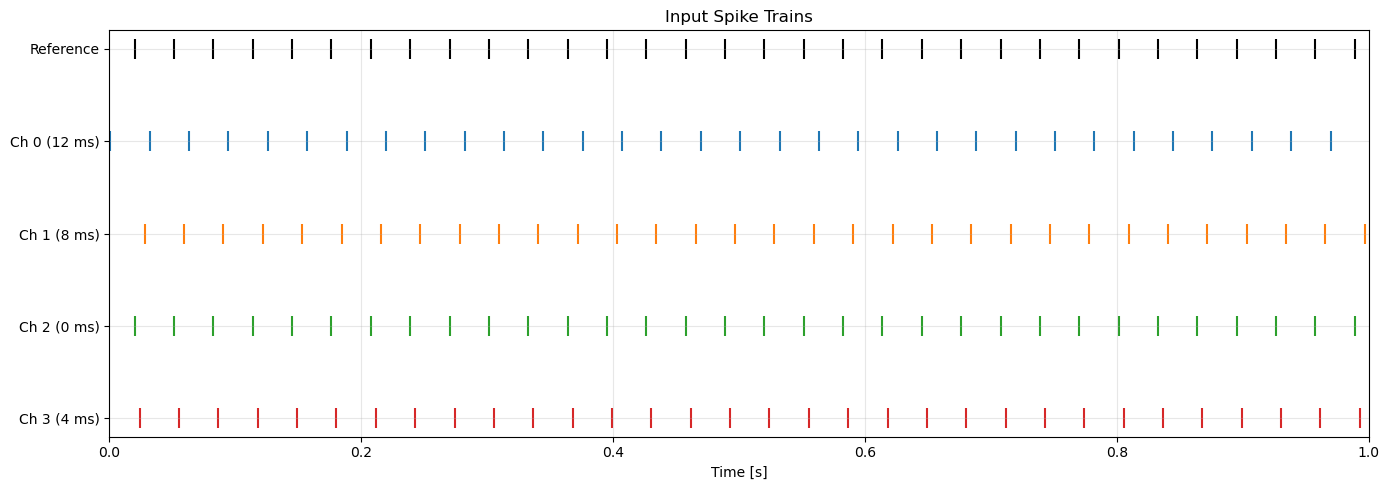

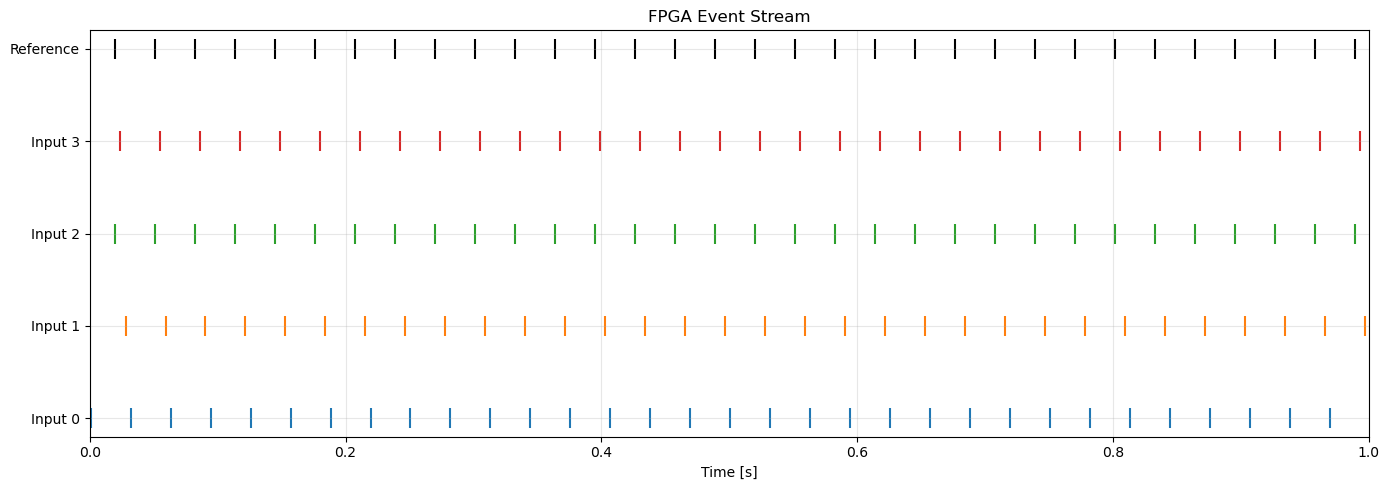

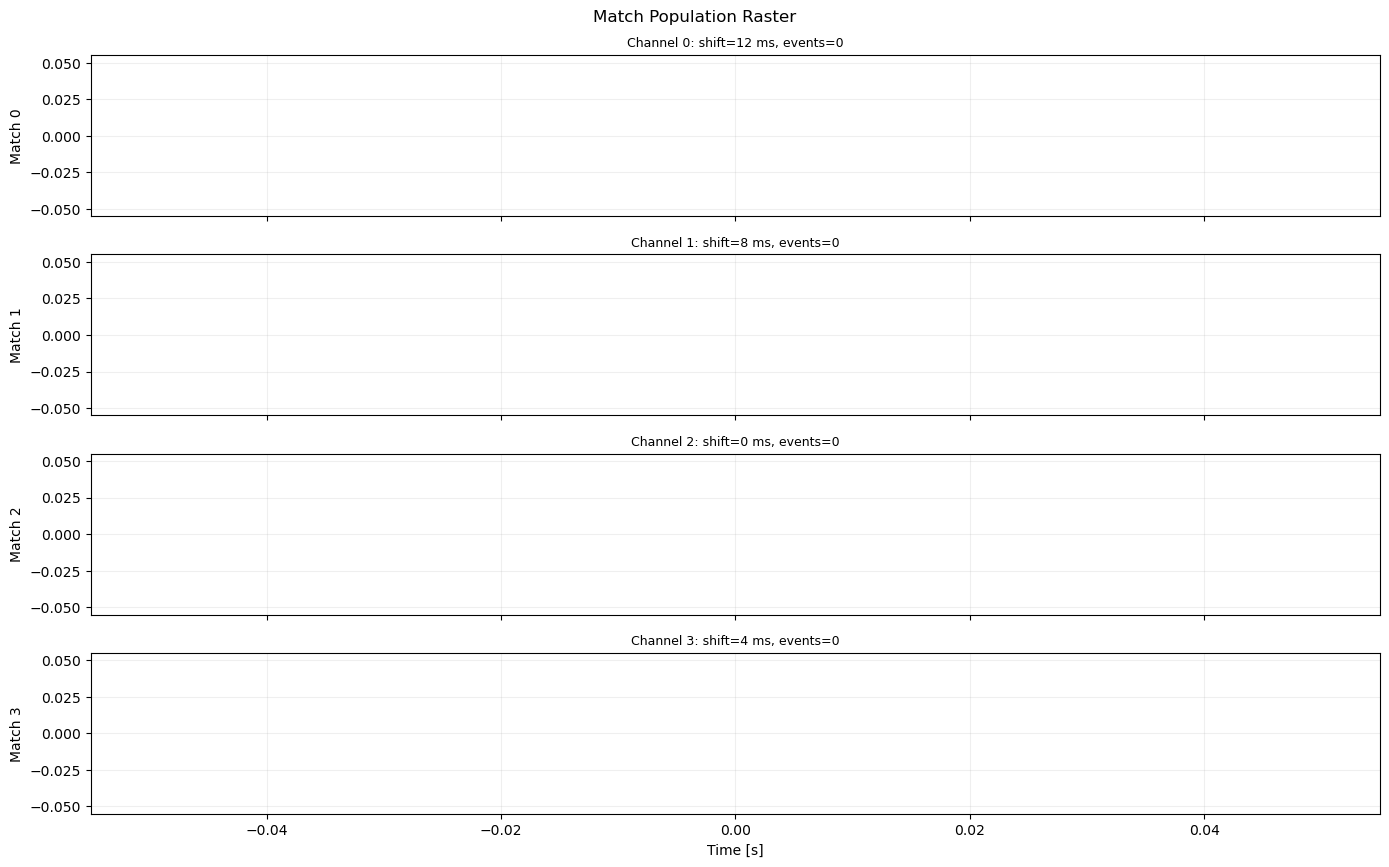

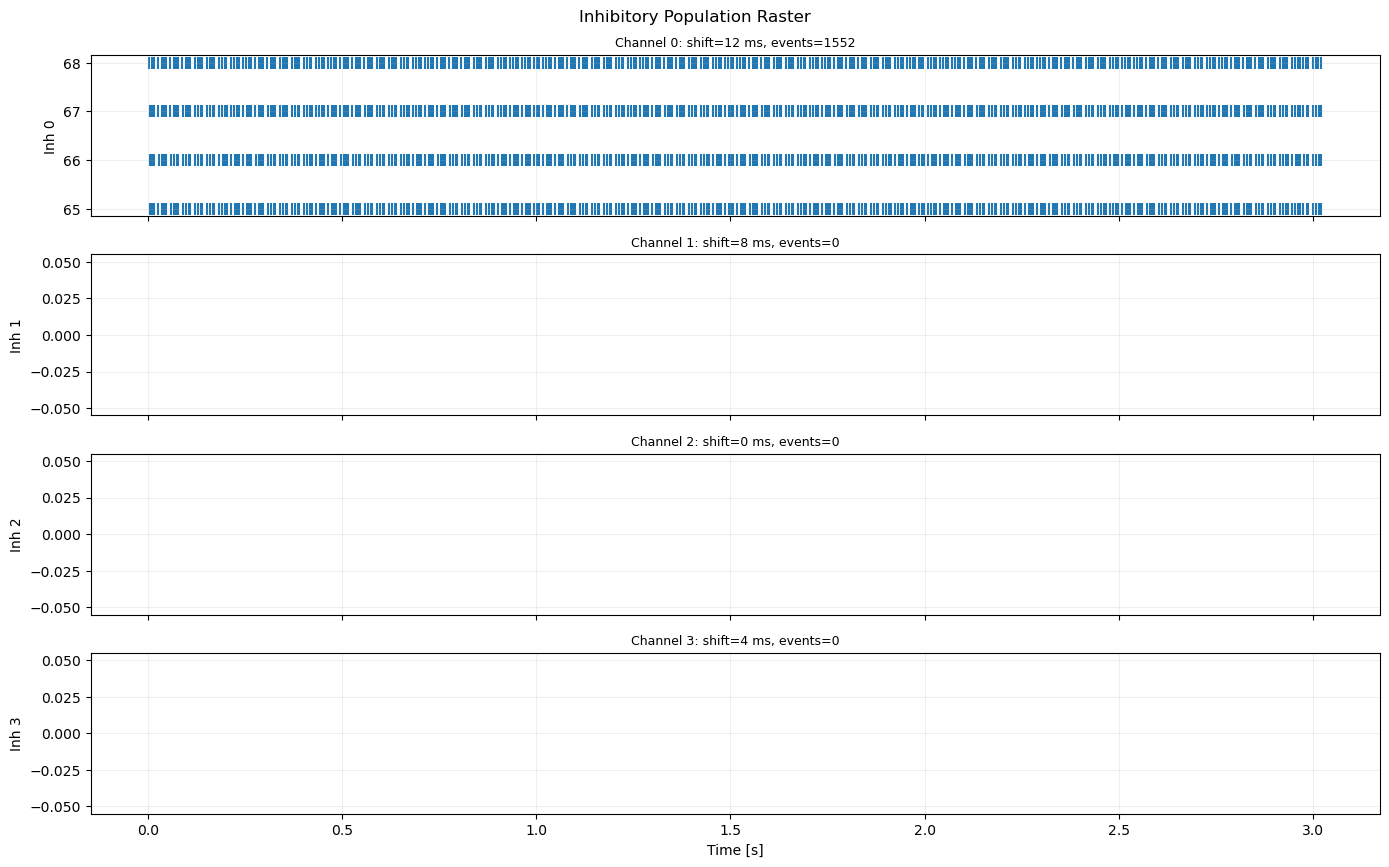

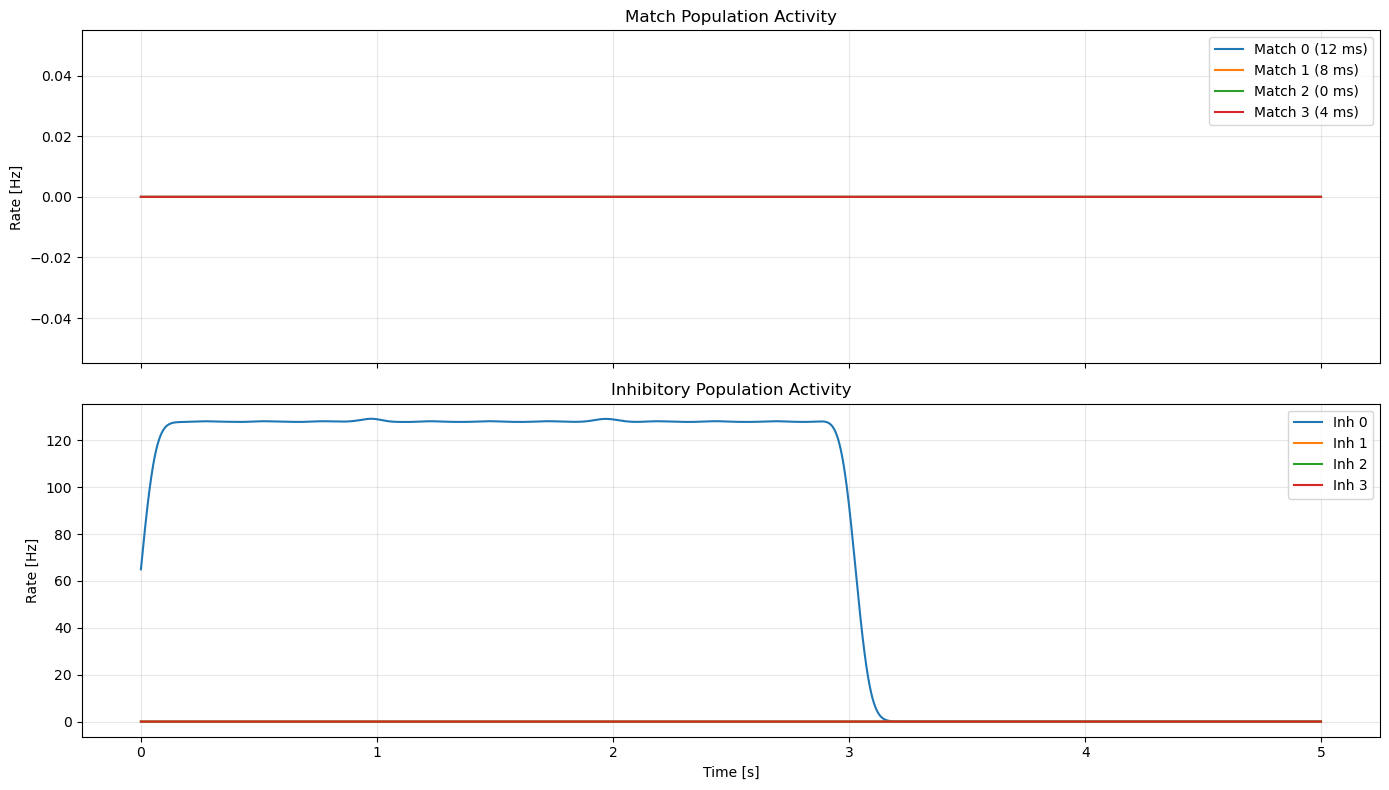

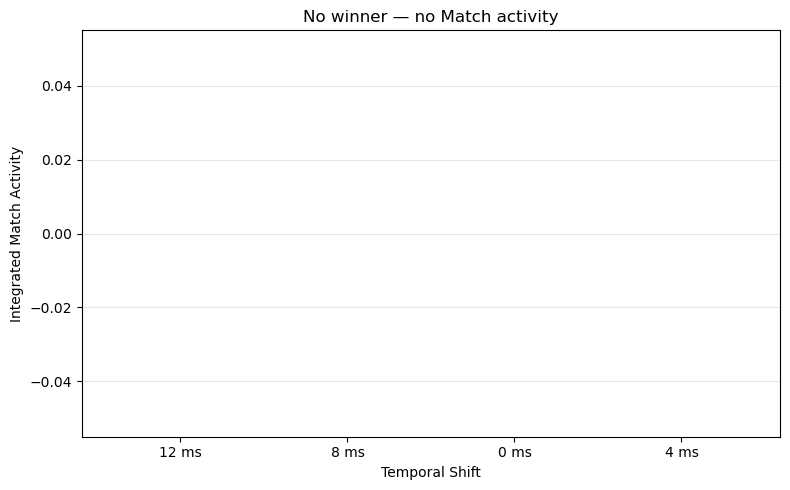

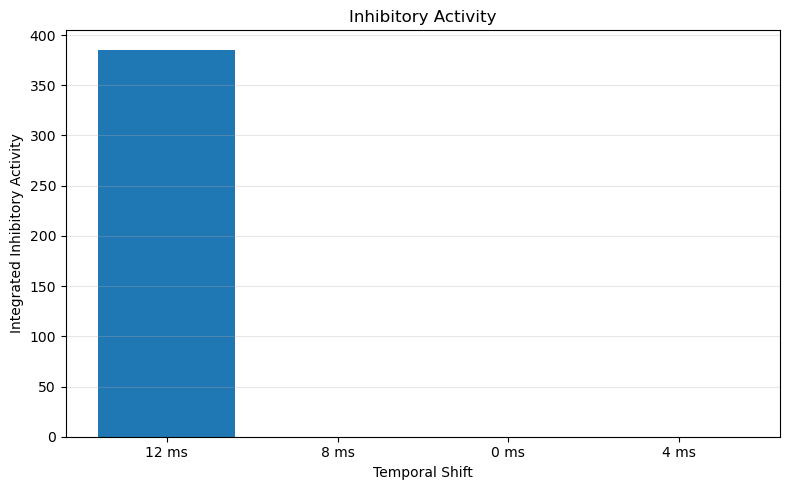


SUMMARY
Ch 0 | shift=    12 ms | Match events=    0 | Inh events= 1552 | Match=  0.000000 | Inh=385.395047
Ch 1 | shift=     8 ms | Match events=    0 | Inh events=    0 | Match=  0.000000 | Inh=  0.000000
Ch 2 | shift=     0 ms | Match events=    0 | Inh events=    0 | Match=  0.000000 | Inh=  0.000000
Ch 3 | shift=     4 ms | Match events=    0 | Inh events=    0 | Match=  0.000000 | Inh=  0.000000

No winner — no Match activity


In [509]:
##############################################################################
# WTA RESULTS AND VISUALIZATION
##############################################################################

# =============================================================================
# DISPLAY SETTINGS
# =============================================================================

COLORS = [plt.get_cmap("tab10")(ch) for ch in range(N_CH)]
SHIFT_LABELS = [f"{shift:g} ms" for shift in CHANNEL_SHIFT_MS]

match_event_counts = np.array([len(get_match_spikes(ch)[0]) for ch in range(N_CH)])
inh_event_counts = np.array([len(get_inh_spikes(ch)[0]) for ch in range(N_CH)])


# =============================================================================
# WINNER DETECTION
# =============================================================================

max_score = float(np.max(match_scores))

if max_score <= WINNER_SCORE_EPSILON:
    winner = None
    winner_text = "No winner — no Match activity"
else:
    winner_candidates = np.flatnonzero(
        np.isclose(match_scores, max_score, rtol=1e-5, atol=WINNER_SCORE_EPSILON)
    )

    if len(winner_candidates) == 1:
        winner = int(winner_candidates[0])
        winner_text = f"Winner = Channel {winner}"
    else:
        winner = None
        winner_text = "Tie: Channels " + ", ".join(str(ch) for ch in winner_candidates)


print("\n" + "=" * 60)
print("WTA RESULT")
print("=" * 60)

for ch in range(N_CH):
    print(
        f"Channel {ch} | shift={CHANNEL_SHIFT_MS[ch]:6g} ms | "
        f"events={match_event_counts[ch]:5d} | "
        f"Match Score={match_scores[ch]:10.6f}"
    )

print(f"\n{winner_text}")
print("=" * 60)


##############################################################################
# PLOT 1 — INPUT SPIKE TRAINS
##############################################################################

fig, ax = plt.subplots(figsize=(14, 5))

ax.scatter(
    t_ref, np.full_like(t_ref, N_CH),
    marker="|", s=200, color="black", label="Reference"
)

for ch in range(N_CH):
    ax.scatter(
        t_ch[ch], np.full_like(t_ch[ch], N_CH - 1 - ch),
        marker="|", s=200, color=COLORS[ch], label=f"Ch {ch}"
    )

ax.set_yticks(np.arange(N_CH + 1))
ax.set_yticklabels(
    [f"Ch {ch} ({CHANNEL_SHIFT_MS[ch]:g} ms)" for ch in reversed(range(N_CH))]
    + ["Reference"]
)
ax.set_xlim(0, T)
ax.set_xlabel("Time [s]")
ax.set_title("Input Spike Trains")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


##############################################################################
# PLOT 2 — FPGA EVENT STREAM
##############################################################################

fig, ax = plt.subplots(figsize=(14, 5))

indices_np = np.asarray(indices)
values_np = np.asarray(values_list)

spikegen_plot_ids = [SPIKEGEN_NEURON[ch] for ch in range(N_CH)] + [REFERENCE_NRN]
spikegen_plot_labels = [f"Input {ch}" for ch in range(N_CH)] + ["Reference"]

for row, neuron_id in enumerate(spikegen_plot_ids):
    mask = indices_np == neuron_id
    ax.scatter(
        values_np[mask], np.full(mask.sum(), row),
        marker="|", s=200, color="black" if neuron_id == REFERENCE_NRN else COLORS[row]
    )

ax.set_yticks(np.arange(N_CH + 1))
ax.set_yticklabels(spikegen_plot_labels)
ax.set_xlim(0, T)
ax.set_xlabel("Time [s]")
ax.set_title("FPGA Event Stream")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()


##############################################################################
# PLOT 3 — MATCH POPULATION RASTER
##############################################################################

fig, axes = plt.subplots(N_CH, 1, figsize=(14, 2.2 * N_CH), sharex=True)
axes = np.atleast_1d(axes)

for ch in range(N_CH):
    t_match, n_match = get_match_spikes(ch)
    axes[ch].scatter(
        t_match, n_match,
        marker="|", s=80, color=COLORS[ch]
    )
    axes[ch].set_ylabel(f"Match {ch}")
    axes[ch].set_title(
        f"Channel {ch}: shift={CHANNEL_SHIFT_MS[ch]:g} ms, "
        f"events={len(t_match)}",
        fontsize=9
    )
    axes[ch].grid(alpha=0.2)

axes[-1].set_xlabel("Time [s]")
fig.suptitle("Match Population Raster")

plt.tight_layout()
plt.show()


##############################################################################
# PLOT 4 — INHIBITORY POPULATION RASTER
##############################################################################

fig, axes = plt.subplots(N_CH, 1, figsize=(14, 2.2 * N_CH), sharex=True)
axes = np.atleast_1d(axes)

for ch in range(N_CH):
    t_inh, n_inh = get_inh_spikes(ch)
    axes[ch].scatter(
        t_inh, n_inh,
        marker="|", s=80, color=COLORS[ch]
    )
    axes[ch].set_ylabel(f"Inh {ch}")
    axes[ch].set_title(
        f"Channel {ch}: shift={CHANNEL_SHIFT_MS[ch]:g} ms, "
        f"events={len(t_inh)}",
        fontsize=9
    )
    axes[ch].grid(alpha=0.2)

axes[-1].set_xlabel("Time [s]")
fig.suptitle("Inhibitory Population Raster")

plt.tight_layout()
plt.show()


##############################################################################
# PLOT 5 — POPULATION FIRING RATES
##############################################################################

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ch in range(N_CH):
    axes[0].plot(
        t_axis, match_rates[ch],
        color=COLORS[ch],
        label=f"Match {ch} ({CHANNEL_SHIFT_MS[ch]:g} ms)"
    )

axes[0].set_ylabel("Rate [Hz]")
axes[0].set_title("Match Population Activity")
axes[0].legend()
axes[0].grid(alpha=0.3)

for ch in range(N_CH):
    axes[1].plot(
        t_axis, inh_rates[ch],
        color=COLORS[ch],
        label=f"Inh {ch}"
    )

axes[1].set_ylabel("Rate [Hz]")
axes[1].set_xlabel("Time [s]")
axes[1].set_title("Inhibitory Population Activity")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


##############################################################################
# PLOT 6 — MATCH SCORE
##############################################################################

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(range(N_CH), match_scores, color=COLORS)
ax.set_xticks(range(N_CH))
ax.set_xticklabels(SHIFT_LABELS)
ax.set_ylabel("Integrated Match Activity")
ax.set_xlabel("Temporal Shift")
ax.set_title(winner_text)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()


##############################################################################
# PLOT 7 — INHIBITORY SCORE
##############################################################################

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(range(N_CH), inh_scores, color=COLORS)
ax.set_xticks(range(N_CH))
ax.set_xticklabels(SHIFT_LABELS)
ax.set_ylabel("Integrated Inhibitory Activity")
ax.set_xlabel("Temporal Shift")
ax.set_title("Inhibitory Activity")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(f"keyspot_plots/InHIntegrat{J_SHIFT_PARAM}.png")
plt.show()


##############################################################################
# SUMMARY
##############################################################################

print("\n" + "=" * 76)
print("SUMMARY")
print("=" * 76)

for ch in range(N_CH):
    print(
        f"Ch {ch} | shift={CHANNEL_SHIFT_MS[ch]:6g} ms | "
        f"Match events={match_event_counts[ch]:5d} | "
        f"Inh events={inh_event_counts[ch]:5d} | "
        f"Match={match_scores[ch]:10.6f} | "
        f"Inh={inh_scores[ch]:10.6f}"
    )

print(f"\n{winner_text}")
print("=" * 76)

In [510]:
print(len(events))

1447


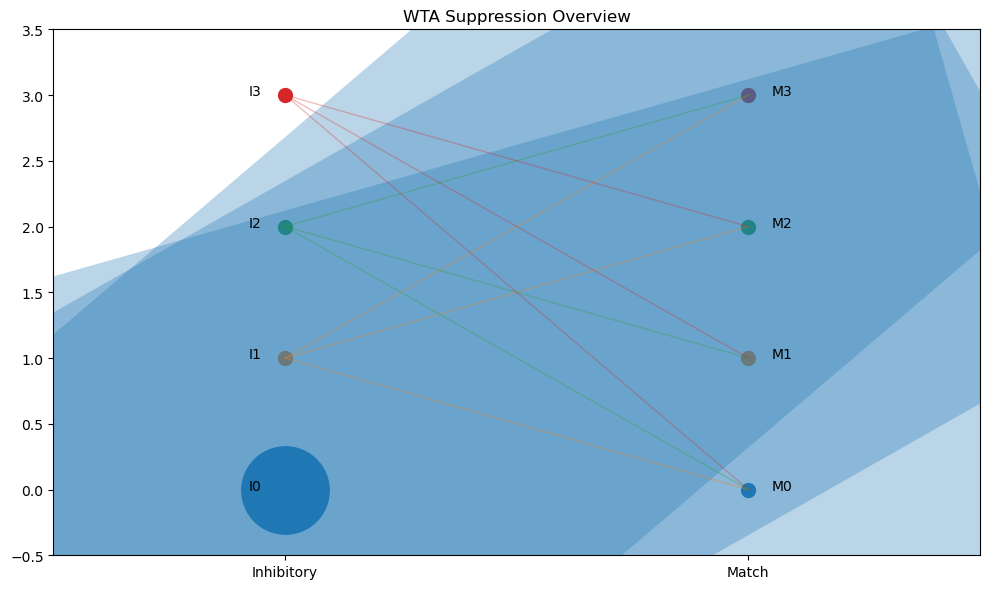

In [511]:
##############################################################################
# SUPPRESSION DEBUG VIEW
#
# Left  = inhibitory population activity
# Right = match population activity
#
# Same color = same channel
#
##############################################################################

fig, ax = plt.subplots(
    figsize=(10,6)
)

for ch in range(N_CH):

    inh_strength = inh_scores[ch]
    match_strength = match_scores[ch]

    # inhibitory node
    ax.scatter(
        0,
        ch,
        s=100 + inh_strength * 10,
        color=COLORS[ch]
    )

    # match node
    ax.scatter(
        1,
        ch,
        s=100 + match_strength * 10,
        color=COLORS[ch]
    )

    ax.text(
        -0.05,
        ch,
        f"I{ch}",
        ha="right"
    )

    ax.text(
        1.05,
        ch,
        f"M{ch}",
        ha="left"
    )

##############################################################################
# DRAW SUPPRESSION CONNECTIONS
##############################################################################

for src in range(N_CH):

    for dst in range(N_CH):

        if src == dst:
            continue

        strength = inh_scores[src]

        ax.plot(
            [0,1],
            [src,dst],
            color=COLORS[src],
            alpha=0.3,
            linewidth=1 + strength
        )

ax.set_xlim(-0.5,1.5)
ax.set_ylim(-0.5,N_CH-0.5)

ax.set_xticks([0,1])
ax.set_xticklabels([
    "Inhibitory",
    "Match"
])

ax.set_title(
    "WTA Suppression Overview"
)

plt.tight_layout()
plt.show()

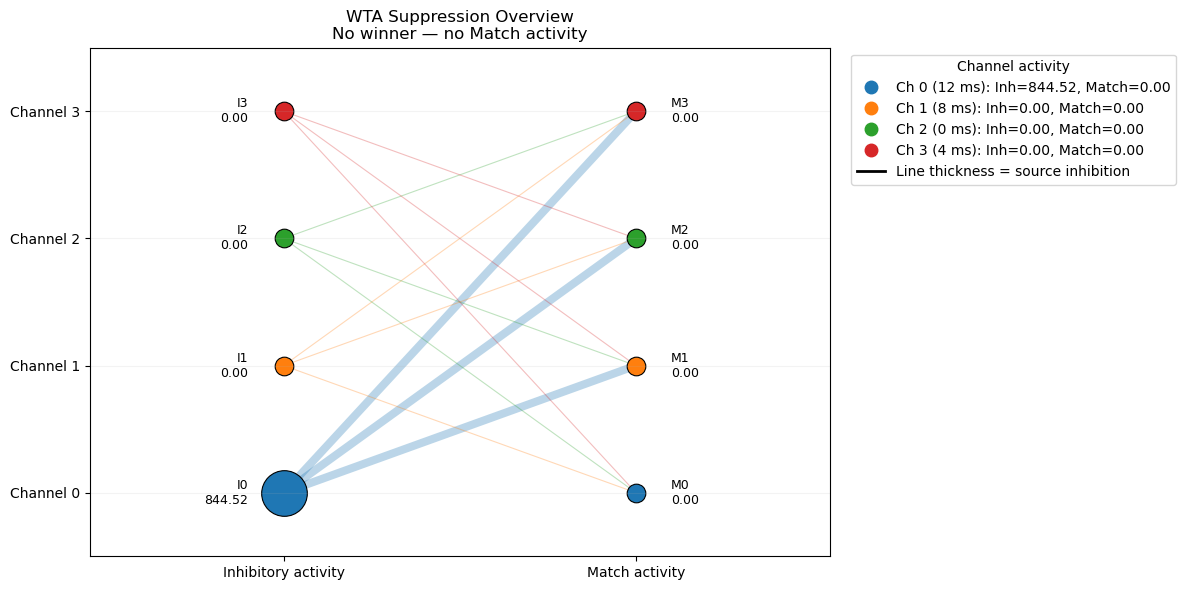

In [498]:
##############################################################################
# PLOT 8 — WTA SUPPRESSION DEBUG VIEW
#
# Left node size  = inhibitory activity
# Right node size = match activity
# Line width      = inhibition produced by source channel
##############################################################################

from matplotlib.lines import Line2D

inh_values = np.asarray(inh_scores, dtype=float)
match_values = np.asarray(match_scores, dtype=float)

inh_scale = max(np.max(inh_values), WINNER_SCORE_EPSILON)
match_scale = max(np.max(match_values), WINNER_SCORE_EPSILON)

inh_sizes = 180 + 900 * inh_values / inh_scale
match_sizes = 180 + 900 * match_values / match_scale
line_widths = 0.8 + 5 * inh_values / inh_scale

fig, ax = plt.subplots(figsize=(12, 6))

##############################################################################
# ACTIVITY NODES
##############################################################################

for ch in range(N_CH):
    ax.scatter(0, ch, s=inh_sizes[ch], color=COLORS[ch], edgecolor="black", linewidth=0.8)
    ax.scatter(1, ch, s=match_sizes[ch], color=COLORS[ch], edgecolor="black", linewidth=0.8)

    ax.text(-0.10, ch, f"I{ch}\n{inh_values[ch]:.2f}", ha="right", va="center", fontsize=9)
    ax.text(1.10, ch, f"M{ch}\n{match_values[ch]:.2f}", ha="left", va="center", fontsize=9)

##############################################################################
# CROSS-CHANNEL SUPPRESSION
##############################################################################

for src in range(N_CH):
    for dst in range(N_CH):
        if src == dst:
            continue

        ax.plot(
            [0, 1], [src, dst],
            color=COLORS[src], alpha=0.30, linewidth=line_widths[src], zorder=0
        )

##############################################################################
# LABELS AND LEGEND
##############################################################################

activity_legend = [
    Line2D(
        [0], [0], marker="o", linestyle="none", color=COLORS[ch],
        markersize=9,
        label=(
            f"Ch {ch} ({CHANNEL_SHIFT_MS[ch]:g} ms): "
            f"Inh={inh_values[ch]:.2f}, Match={match_values[ch]:.2f}"
        )
    )
    for ch in range(N_CH)
]

line_legend = Line2D(
    [0], [0], color="black", linewidth=2,
    label="Line thickness = source inhibition"
)

ax.legend(
    handles=activity_legend + [line_legend],
    title="Channel activity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

ax.set_xlim(-0.55, 1.55)
ax.set_ylim(-0.5, N_CH - 0.5)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Inhibitory activity", "Match activity"])
ax.set_yticks(range(N_CH))
ax.set_yticklabels([f"Channel {ch}" for ch in range(N_CH)])
ax.set_title(f"WTA Suppression Overview\n{winner_text}")
ax.grid(axis="y", alpha=0.15)

plt.tight_layout()
plt.show()

### Since this is working(Llookslike), we build an slider for attribute tunning:

In [499]:
def run_experiment(
    ampa_tau,
    gaba_tau,
    threshold,
    leak
):

    param_group["AMPA_TAU"] = ampa_tau
    param_group["GABA_TAU"] = gaba_tau
    param_group["THRESHOLD"] = threshold
    param_group["LEAK"] = leak

    set_params(
        model,
        param_group=param_group
    )

    # run network

    # plot scores

In [500]:
from ipywidgets import interact

print(param_group)

dynapse1::Dynapse1ParameterGroup param_map={ { IF_AHTAU_N :  } { IF_AHTHR_N :  } { IF_AHW_P :  } { IF_BUF_P :  } { IF_CASC_N :  } { IF_DC_P :  } { IF_NMDA_N :  } { IF_RFR_N :  } { IF_TAU1_N :  } { IF_TAU2_N :  } { IF_THR_N :  } { NPDPIE_TAU_F_P :  } { NPDPIE_TAU_S_P :  } { NPDPIE_THR_F_P :  } { NPDPIE_THR_S_P :  } { NPDPII_TAU_F_P :  } { NPDPII_TAU_S_P :  } { NPDPII_THR_F_P :  } { NPDPII_THR_S_P :  } { PS_WEIGHT_EXC_F_N :  } { PS_WEIGHT_EXC_S_N :  } { PS_WEIGHT_INH_F_N :  } { PS_WEIGHT_INH_S_N :  } { PULSE_PWLK_P :  } { R2R_P :  } }, core_id=0, chip_id=0.


In [501]:
from ipywidgets import interact

def tune_network(

    gaba_b_weight,
    gaba_a_weight,

    nmda_tau,
    ampa_tau,

    gaba_b_tau,
    gaba_a_tau

):

    ##################################################################
    # GABA B
    ##################################################################

    param_group.param_map[
        "PS_WEIGHT_INH_S_N"
    ].fine_value = gaba_b_weight

    ##################################################################
    # GABA A
    ##################################################################

    param_group.param_map[
        "PS_WEIGHT_INH_F_N"
    ].fine_value = gaba_a_weight

    ##################################################################
    # NMDA
    ##################################################################

    param_group.param_map[
        "NPDPIE_TAU_S_P"
    ].fine_value = nmda_tau

    ##################################################################
    # AMPA
    ##################################################################

    param_group.param_map[
        "NPDPIE_TAU_F_P"
    ].fine_value = ampa_tau

    ##################################################################
    # INH FAST
    ##################################################################

    param_group.param_map["NPDPII_TAU_F_P" ].fine_value = gaba_a_tau

    ##################################################################
    # INH SLO
    param_group.param_map["NPDPII_TAU_S_P"].fine_value = gaba_b_tau

#APPLY##################################################################
    set_params(
        model,
        param_group=param_group
    )

    print("\nCurrent Parameters\n")
    print(f"GABA_B_WEIGHT : {gaba_b_weight}")
    print(f"GABA_A_WEIGHT : {gaba_a_weight}")
    print(f"NMDA_TAU      : {nmda_tau}")
    print(f"AMPA_TAU      : {ampa_tau}")
    print(f"GABA_B_TAU    : {gaba_b_tau}")
    print(f"GABA_A_TAU    : {gaba_a_tau}")

In [502]:
interact(

    tune_network,

    gaba_b_weight=(0,255,1),
    gaba_a_weight=(0,255,1),

    nmda_tau=(0,255,1),
    ampa_tau=(0,255,1),

    gaba_b_tau=(0,255,1),
    gaba_a_tau=(0,255,1)

)

interactive(children=(IntSlider(value=127, description='gaba_b_weight', max=255), IntSlider(value=127, descrip…

<function __main__.tune_network(gaba_b_weight, gaba_a_weight, nmda_tau, ampa_tau, gaba_b_tau, gaba_a_tau)>

In [ ]:
for fine in [80,120,160,200,240]:

    param_group.param_map[
        'PS_WEIGHT_EXC_F_N'
    ].fine_value = fine

    set_params(
        model,
        param_group
    )

    run_experiment()

    print(
        fine,
        match_scores
    )

In [ ]:
get_bias("PS_WEIGHT_EXC_F_N")

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
# 9. PLOT  — 4 rows (channels) × 3 cols (raster | phase | signed rate)
#            exactly like the tutorial EI_balance plot
# ─────────────────────────────────────────────────────────────────────────────

NN   = 256   # neurons per core on DynapseSE1
fs   = 200
D    = D_stim + D_post

# global spike id  (core * NN + neuron_id)  — same trick as tutorial
spike_id = spike_core * NN + spike_nrn

# Gaussian kernel (same as tutorial)
sigma = 0.01
x     = np.arange(int(-0.2 * fs), int(0.2 * fs)) / fs
gauss = np.exp(-x**2 / sigma)

# global ID ranges per channel
#   core 0, E: ch0→1-4, ch1→5-8, ch2→9-12, ch3→13-16
#   core 0, I: ch0→17-20, ch1→21-24, ch2→25-28, ch3→29-32
def g_range(ch):
    e_lo = 0*NN + 1  + ch * NE_CH      # global
    e_hi = e_lo + NE_CH
    i_lo = 0*NN + 17 + ch * NI_CH
    i_hi = i_lo + NI_CH
    return e_lo, e_hi, i_lo, i_hi

COLORS     = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
stim_bins  = int(D_stim * fs)
post_bins  = int(D_post  * fs)
t_stim_ax  = np.arange(stim_bins) / fs
t_post_ax  = np.arange(post_bins) / fs + D_stim
t_all_ax   = np.arange(int(D * fs)) / fs

fig, axes = plt.subplots(N_CH, 3, figsize=(20, 4 * N_CH))
fig.suptitle("4-Channel WTA — EI dynamics per channel", fontsize=14)

for ch in range(N_CH):
    e_lo, e_hi, i_lo, i_hi = g_range(ch)

    mask_E = (spike_id >= e_lo) & (spike_id < e_hi)
    mask_I = (spike_id >= i_lo) & (spike_id < i_hi)

    t_E  = spike_t[mask_E];  id_E = spike_id[mask_E]
    t_I  = spike_t[mask_I];  id_I = spike_id[mask_I]

    # binned population activity
    binPOP = np.zeros((2, int(D * fs)))
    for t in t_E:
        if 0 <= t < D:
            binPOP[0, int(t * fs)] = 1
    for t in t_I:
        if 0 <= t < D:
            binPOP[1, int(t * fs)] = 1

    binPOP[0] = np.convolve(binPOP[0], gauss, 'same')
    binPOP[1] = np.convolve(binPOP[1], gauss, 'same')

    ax1, ax2, ax3 = axes[ch]

    # ── raster ───────────────────────────────────────────────────────────
    ax1.scatter(t_E, id_E, marker='|', s=40, color=COLORS[ch], label='E')
    ax1.scatter(t_I, id_I, marker='|', s=40, color='gray',     label='I', alpha=0.7)
    ax1.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.set_xlim(0, D)
    ax1.set_title(f"Ch {ch}  ε={J_SHIFT_PARAM[ch]}ms  |  {mask_E.sum()}E / {mask_I.sum()}I spikes")
    ax1.legend(fontsize=7)

    # ── phase portrait ───────────────────────────────────────────────────
    ax2.scatter(binPOP[0, :stim_bins] / NE_CH,
                binPOP[1, :stim_bins] / NI_CH,
                c='k', s=5, label='During stimulus')
    ax2.scatter(binPOP[0, stim_bins:] / NE_CH,
                binPOP[1, stim_bins:] / NI_CH,
                c='red', s=5, label='Post stimulus')
    ax2.set_xlabel('firing rate E POP')
    ax2.set_ylabel('firing rate I POP')
    ax2.legend(fontsize=7)

    # ── signed firing rate ───────────────────────────────────────────────
    ax3.plot(t_all_ax,  binPOP[0] / NE_CH, color=COLORS[ch], label='E')
    ax3.plot(t_all_ax, -binPOP[1] / NI_CH, color='gray',     label='I')
    ax3.plot(t_stim_ax,
             binPOP[0, :stim_bins] / NE_CH - binPOP[1, :stim_bins] / NI_CH,
             c='k', label='E-I During stim.')
    ax3.plot(t_post_ax,
             binPOP[0, stim_bins:] / NE_CH - binPOP[1, stim_bins:] / NI_CH,
             c='red', label='E-I Post stim.')
    ax3.axhline(0, color='gray', lw=0.8)
    ax3.axvline(D_stim, color='k', lw=0.8, ls='--')
    ax3.set_xlabel('time (s)')
    ax3.set_ylabel('signed firing rate')
    ax3.set_ylim(-2, 2)
    ax3.legend(loc='lower left', ncol=2, fontsize=7)

plt.figtext(
    0.5, 0.005,
    f"p_SG_E={p_SG_E}  p_E_I={p_E_I}  p_I_I={p_I_I}  p_I_E={p_I_E}  |  "
    f"NE={NE_CH} NI={NI_CH}/ch  |  shifts={J_SHIFT_PARAM}ms",
    ha='center', fontsize=8
)
plt.tight_layout(rect=[0, 0.02, 1, 1])
plt.savefig("keyspot_plots\step3_wta_result.png", dpi=150)
plt.show()
print("Saved: step3_wta_result.png")

In [ ]:
# print AMPA weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

In [ ]:
param_group = config1.chips[0].cores[0].parameter_group 

In [ ]:
# set AMPA (fast excitatory) weight 

param_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value = 160
param_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value = 4


In [ ]:
# print AMPA (fast excitatory) weight values

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_F_N'].fine_value))

In [ ]:
# set NMDA (slow excitatory) weight

param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 180
param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 4

# param_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value = 0
# param_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value = 0

In [ ]:
# print NMDA (slow excitatory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_EXC_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_EXC_S_N'].fine_value))

In [ ]:
# set GABA B (slow inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_S_N'].fine_value = 150
param_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value = 4

In [ ]:
# print GABA B (slow inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_S_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_S_N'].fine_value))

In [ ]:
# set GABA A (fast inhibitory) weight

param_group.param_map['PS_WEIGHT_INH_F_N'].fine_value = 200
param_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value = 4

In [ ]:
# print GABA A (fast inhibitory) weight

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('PS_WEIGHT_INH_F_N')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['PS_WEIGHT_INH_F_N'].fine_value))

In [ ]:
# set NMDA (slow exc) tau 
# remember the higher the tau param, the higher the leak, the faster the decay

param_group.param_map['NPDPIE_TAU_S_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_S_P'].coarse_value = 4

In [ ]:
# print NMDA (slow exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_S_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P'].fine_value))

In [ ]:
# # set AMPA (fast exc) tau 

param_group.param_map['NPDPIE_TAU_F_P'].fine_value = 10
param_group.param_map['NPDPIE_TAU_F_P'].coarse_value = 4

In [ ]:
# print AMPA (fast exc) tau 

print("Linear: " + str(config1.chips[0].cores[0].parameter_group.get_linear_parameter('NPDPIE_TAU_F_P')))
print("Coarse: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].coarse_value))
print("Fine: " + str(config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_F_P'].fine_value))

In [ ]:
param_group.param_map["NPDPII_TAU_F_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_F_P"].fine_value = 8

param_group.param_map["NPDPII_TAU_S_P"].coarse_value = 4
param_group.param_map["NPDPII_TAU_S_P"].fine_value = 8

In [ ]:
#config1 = model.get_configuration() 

### checl range of params 
param = config1.chips[0].cores[0].parameter_group.param_map['NPDPIE_TAU_S_P']
print(param)
dir(param)
type(param.coarse_value)
print(param.coarse_value)

In [ ]:
#import importlib # Module to dynamically reload modules
#importlib.reload(params) # Reloads the params module to ensure any changes are recognized

###what does this actually do ? 
model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

p_INP_E = 0.95       # Probability of connections from spike generator to excitatory population
p_E_E   = 0.15        # Probability of connections among excitatory neurons
p_I_I   = 0.1           # Probability of connections among inhibitory neurons
p_E_I   = 0.2      # Probability of connections from excitatory to inhibitory
p_I_E   = 0.1          # Probability of connections from inhibitory to excitatory

# p_INP_E = .7            # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.1          # Probability of connections among excitatory neurons
# p_I_I   = 0.5             # Probability of connections among inhibitory neurons
# p_E_I   = 0.2           # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.5 

#### Given 

#model.update_parameter_group(param_group, 0, 0) # update params based on the params you changed 

# p_INP_E = 1             # Probability of connections from spike generator to excitatory population
# p_E_E   = 0.8             # Probability of connections among excitatory neurons
# p_I_I   = 0.0             # Probability of connections among inhibitory neurons
# p_E_I   = 0.5             # Probability of connections from excitatory to inhibitory
# p_I_E   = 0.0             # Probability of connections from inhibitory to excitatory

# We use CHIP 0 in this exercise 
    # remember, there are 4 chips per every blue box. There are 4 cores per every chip. There are 256 neurons per every core.
    
# We are using a SPIKEGEN located  in CORE 1. POPULATION E is in CORE 0. POPULATION I is in CORE 0.
    # when you set up your own EI balanced networks in the future, we advise that you keep the POPULATION E and POPULATION I in different cores to more easily control the parameters

# Create a NetworkGenerator object to build the network configuration:
net_gen = NetworkGenerator()
net_gen.clear_network() # Clear any existing network structure

# We will create a spike generator in chip=0, core=1, neuron=1

spikegen_ids = [(0, 1, 1)]
spikegens = []
for spikegen_id in spikegen_ids:
    spikegens.append(Neuron(spikegen_id[0],spikegen_id[1],spikegen_id[2],True))
## YOYO accumulkates the spikes in given frequency and precise timing sending to the location of spike:ids @ the chip 




# Define the size of the excitatory population and create their neuron IDs:
NE    = 40
E_ids = [(0,0,ni) for ni in range(1,NE)]
neurons_E = []
for nid in E_ids:
    neurons_E.append(Neuron(nid[0],nid[1],nid[2]))


# Define the size of the inhibitory population and create their neuron IDs
NI    = 40
I_ids = [(0,0,ni+NE) for ni in range(1,NI)]
neurons_I = []
for nid in I_ids:
    neurons_I.append(Neuron(nid[0],nid[1],nid[2]))


# connect SPIKEGEN to POPULATION E:
for i in range(int(NE*p_INP_E)-1):
    # Here, we connect from spikegens[0] to neurons_E[i]
    # using the AMPA synapse type
    net_gen.add_connection(spikegens[0], neurons_E[i], dyn1.Dynapse1SynType.AMPA)

# connect POPULATION E to POPULATION E
    # (Connect excitatory neurons among themselves (E to E) with probability p_E_E)
counter=0
for i in range(NE-1):
    for j in range(NE-1):
        if(i!=j and p_E_E > np.random.uniform()):
            counter+=1
            # Use NMDA synapse type for these connections. So you can tune the parameters of the NMDA and AMPA synapses separately
            net_gen.add_connection(neurons_E[i], neurons_E[j], dyn1.Dynapse1SynType.NMDA)
print(str(counter)+" NMDA synapses")
            
# connect POPULATION E to POPULATION I
for i in range(NE-1):
    for j in range(NI-1):
        if(p_E_I > np.random.uniform()):
            net_gen.add_connection(neurons_E[i], neurons_I[j], dyn1.Dynapse1SynType.AMPA)


# connect POPULATION I to POPULATION I 
for i in range(NI-1):
    for j in range(NI-1):
        if(i!=j and p_I_I > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_I[j], dyn1.Dynapse1SynType.GABA_A)


# connect POPULATION I to POPULATION E
for i in range(NI-1):
    for j in range(NE-1):
        if(p_I_E > np.random.uniform()):
            net_gen.add_connection(neurons_I[i], neurons_E[j], dyn1.Dynapse1SynType.GABA_B)

# make a dynapse1config using the network
new_config = net_gen.make_dynapse1_configuration()

# apply the configuration
model.apply_configuration(new_config)


for rate in [50]:
    D_stim = 3 # stimulus duration (s)
    D_post_stim = 3 # post stimulus duration (s)
    D = D_stim + D_post_stim
    global_poisson_gen_ids = ut.get_global_id_list(spikegen_ids)
    poisson_gen = model.get_poisson_gen()
    poisson_gen.set_chip_id(0)
    poisson_gen.write_poisson_rate_hz(global_poisson_gen_ids[0], rate)
    
    # set parameters
### turned of 
    #set_params(model)#, param_group = param_group) # note here: set_params(model) will revert the params back to the standard params
### newly setted for changing behavior
    set_params(model, param_group = param_group)
    # if you want to use new parameters that you set via this script, you need to use set_params(model, param_group = param_group)
    
    
    # how to get events of selected neurons
    monitored_neurons = E_ids + I_ids
    graph, filter_node, sink_node = ut.create_neuron_select_graph(model, monitored_neurons)

### create graphs have to be stopped____________________________________________
    graph.start()

    # start the poisson gen
    poisson_gen.start()

    # select the neurons to monitor
    print("monitored neurons:", monitored_neurons)
    filter_node.set_neurons(monitored_neurons)

    # clear the buffer
    sink_node.get_events()

    api.reset_timestamp()
    time.sleep(D_stim)

    poisson_gen.stop()
    time.sleep(D_post_stim)
    graph.stop()
    events = sink_node.get_events()
    
### create graphs have to be stopped____________________________________________

    # process the events
    print(len(events),"events.")

    NN = 256 # neurons in 1 core
    spike_id = []
    spike_t  = []
    for evt in events:
        spike_id.append(evt.core_id*NN + evt.neuron_id)
        spike_t.append(evt.timestamp*1e-6)
    spike_id = np.array(spike_id)
    spike_t  = np.array(spike_t) 

    # E mean firing rate
    fs = 200
    binPOP = np.zeros((2,int(D*fs)))
    for i in range(len(events)):
        if(spike_t[i]<D):
            binPOP[spike_id[i]//NE,int(spike_t[i]*fs)]=1

    sigma = 0.01
    x = np.arange(int(-0.2*fs),int(0.2*fs))/fs
    gauss = np.exp(-x**2/sigma)

    binPOP[0] = np.convolve(binPOP[0],gauss,'same')
    binPOP[1] = np.convolve(binPOP[1],gauss,'same')

    f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20,4))

    ax1.scatter(spike_t[spike_id<(NE)],spike_id[spike_id<(NE)],marker='|',label='E')
    ax1.scatter(spike_t[spike_id>(NE)],spike_id[spike_id>(NE)],marker='|',label='I')
    ax1.set_xlabel('time (s)')
    ax1.set_ylabel('neuron id')
    ax1.legend()
    ax1.set_xlim(0,D)


    ax2.scatter(binPOP[0,:int(D_stim*fs)]/NE,binPOP[1,:int(D_stim*fs)]/NI,c='k',s=5,label='During stimulus')
    ax2.scatter(binPOP[0,int(D_stim*fs):]/NE,binPOP[1,int(D_stim*fs):]/NI,c='red',s=5,label='Post stimulus')
    ax2.set_ylabel('firing rate I POP')
    ax2.set_xlabel('firing rate E POP')
    ax2.legend()

    ax3.plot(np.arange(int(D*fs))/fs,binPOP[0]/NE,label='E')
    ax3.plot(np.arange(int(D*fs))/fs,-binPOP[1]/NI,label='I')
    ax3.plot(np.arange(int(D_stim*fs))/fs,binPOP[0,:int(D_stim*fs)]/NE-binPOP[1,:int(D_stim*fs)]/NI,c='k',label='E-I During stim.')
    ax3.plot(np.arange(int(D_post_stim*fs))/fs+int(D_stim*fs)/fs,binPOP[0,int(D_stim*fs):]/NE-binPOP[1,int(D_stim*fs):]/NI,c='red',label='E-I Post stim.')
    ax3.plot([0,D],[0,0],'gray')
    ax3.set_ylabel('signed firing rate')
    ax3.set_xlabel('time (s)')
    ax3.legend(loc='lower left', ncol=2)
    ax3.set_ylim(-2,2)

###write param to pic

    param = param_group.param_map['NPDPIE_TAU_F_P']

    plt.subplots_adjust(bottom=0.1)
    plt.figtext(0.5, 0.001, f"p_INP_E={p_INP_E}, p_E_E={p_E_E}, p_I_I={p_I_I}, p_E_I={p_E_I} | p_I_E={p_I_E}\n"     f"AMPA TAU: coarse={param.coarse_value}, fine={param.fine_value}",ha="center", fontsize=9)

    plt.tight_layout()
    #plt.savefig('EI.png')
    #plt.savefig(f"./plots/NMDA_syn_{counter}_{p_INP_E}_plt.png")
    plt.show()

Can you achieve something similar as the below figure?

In [ ]:
Image("../lab5/EI_balance.png")